# <center> Traffic Sign Detection</center>

Traffic signs are important as they help the drivers to follow traffic rules and reduce the number of accidents on road. However, it is often very difficult for a driver to focus on the signs along with the other happenings on the road. In addition to this, traffic sign detection is also very important for the fast growing technology of automated driving and driverless cars.

In this notebook we use the [German Traffic Sign Recognition Benchmark](https://www.kaggle.com/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign) dataset, which contains 43 traffic sign classes. We train a Convolutional Neural Network (CNN) to classify the signs and evaluate it on a held-out split.

Importing necessary libraries

In [1]:
import sys


In [2]:
import numpy as np

In [3]:
import pandas as pd

In [4]:
import os

In [5]:
import importlib

In [6]:
import sys

In [7]:
import random

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [9]:
import tensorflow as tf

In [10]:
from tensorflow.keras import models, layers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


Reading the Data

Firstly, we are setting the seeds in order to make the code reproductible

In [11]:
seed_value = 1 #set the seed for the data
random.seed(seed_value) #the seed for the random module
np.random.seed(seed_value) #this is the seed for NumPy functions
tf.random.set_seed(seed_value) # the samem but it is for TensorFlow

the function used to reset the seed for the models

In [12]:
from tensorflow.keras import backend as K
def reset_everything(seed=1):
    K.clear_session()
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


In [13]:
project_path = os.getcwd() #this get me the corrent working director to save the folder where is the notebook
dataset_path = os.path.join(project_path, 'archive-2') # this is merging the current projrct folder and archive2
train_path = os.path.join(dataset_path, 'Train') #this builds the path to the traing images folder within the dataset
loader_path = os.path.join(project_path, 'traffic_sign_load.py') #this builds the path to the .py files that we receive to open the data

In [ ]:
if not os.path.isdir(train_path):
    raise FileNotFoundError(f'Train folder is not found: {train_path}')

if not os.path.exists(loader_path):
    raise FileNotFoundError(f'traffic_sign_load.py is not found: {loader_path}')

FileNotFoundError: Train folder is not found: /content/archive-2/Train

In [ ]:
#a dictonary with class ID as the key and class name as the value
class_names = {
    0: 'Speed limit (20)', 1: 'Speed limit (30)', 2: 'Speed limit (50)', 3: 'Speed limit (60)',
    4: 'Speed limit (70)', 5: 'Speed limit (80)', 6: 'End speed limit(80)', 7: 'Speed limit (100)',
    8: 'Speed limit (120)', 9: 'No passing', 10: 'No passing >3.5t', 11: 'Right-of-way',
    12: 'Priority road', 13: 'Yield', 14: 'Stop', 15: 'No vehicles', 16: 'No >3.5t vehicles',
    17: 'No entry', 18: 'General caution', 19: 'Danger curve left', 20: 'Danger curve right',
    21: 'Double curve', 22: 'Bumpy road', 23: 'Slippery road', 24: 'Road narrows',
    25: 'Road work', 26: 'Traffic signals', 27: 'Pedestrians', 28: 'Children crossing',
    29: 'Bicycles crossing', 30: 'Ice/snow', 31: 'Wild animals', 32: 'End speed+passing',
    33: 'Turn right ahead', 34: 'Turn left ahead', 35: 'Ahead only', 36: 'Go straight/right',
    37: 'Go straight/left', 38: 'Keep right', 39: 'Keep left', 40: 'Roundabout',
    41: 'End no passing', 42: 'End no passing >3.5t'
}

In [ ]:
datal = []
labelsl = []
classnr = 43

In [ ]:
for class_id in range(classnr):
    class_folder = os.path.join(train_path, str(class_id))
    if not os.path.isdir(class_folder): #checks if the class exist, if not it continues
        continue
    for img_name in os.listdir(class_folder):
        if img_name.endswith('.png'): #this checks if it is a png
            img_path = os.path.join(class_folder, img_name)
            im = Image.open(img_path) #this opens the images
            im = im.resize((32,32)) #image size
            im = np.array(im) #into NumPy array
            datal.append(im) # this add processed image array
            labelsl.append(class_id) #this add class label of that images

data = np.array(datal)
labels = np.array(labelsl)

NameError: name 'classnr' is not defined

In [ ]:
print('Using dataset from:', dataset_path)
print('Using loader reference from:', loader_path)
print('Data shape:', data.shape)
print('Labels shape:', labels.shape)


Using dataset from: /content/archive-2
Using loader reference from: /content/traffic_sign_load.py


NameError: name 'data' is not defined

This code is used only for colab the rest code should work just fine without this code box. If you are using colab just run this and the imports. If you are using vs code please run all the code boxes besides this one

In [14]:
import os
import random
import zipfile
import urllib.request
import numpy as np
import tensorflow as tf
from PIL import Image

seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

project_path = os.getcwd()

def find_dataset_root(base_path):
    candidate_paths = [
        os.path.join(base_path, "archive-2"),
        base_path,
        "/content/archive-2",
        "/content"
    ]

    for path in candidate_paths:
        if os.path.isdir(os.path.join(path, "Train")):
            return path
    return None

dataset_path = find_dataset_root(project_path)

# Download only if the dataset is not already available
if dataset_path is None:
    dataset_url = "https://zenodo.org/records/13741936/files/data.zip?download=1"
    zip_path = os.path.join(project_path, "gtsrb.zip")
    dataset_path = os.path.join(project_path, "archive-2")

    os.makedirs(dataset_path, exist_ok=True)

    print("Dataset not found. Downloading from Zenodo...")
    urllib.request.urlretrieve(dataset_url, zip_path)

    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(dataset_path)

    os.remove(zip_path)

    # Handle the case where unzip creates an extra folder level
    if not os.path.isdir(os.path.join(dataset_path, "Train")):
        for name in os.listdir(dataset_path):
            possible_root = os.path.join(dataset_path, name)
            if os.path.isdir(os.path.join(possible_root, "Train")):
                dataset_path = possible_root
                break

train_path = os.path.join(dataset_path, "Train")

if not os.path.isdir(train_path):
    raise FileNotFoundError(f"Train folder not found: {train_path}")

loader_candidates = [
    os.path.join(project_path, "traffic_sign_load.py"),
    "/content/traffic_sign_load.py"
]
loader_path = next((path for path in loader_candidates if os.path.exists(path)), None)

class_names = {
    0: "Speed limit (20)", 1: "Speed limit (30)", 2: "Speed limit (50)", 3: "Speed limit (60)",
    4: "Speed limit (70)", 5: "Speed limit (80)", 6: "End speed limit(80)", 7: "Speed limit (100)",
    8: "Speed limit (120)", 9: "No passing", 10: "No passing >3.5t", 11: "Right-of-way",
    12: "Priority road", 13: "Yield", 14: "Stop", 15: "No vehicles", 16: "No >3.5t vehicles",
    17: "No entry", 18: "General caution", 19: "Danger curve left", 20: "Danger curve right",
    21: "Double curve", 22: "Bumpy road", 23: "Slippery road", 24: "Road narrows",
    25: "Road work", 26: "Traffic signals", 27: "Pedestrians", 28: "Children crossing",
    29: "Bicycles crossing", 30: "Ice/snow", 31: "Wild animals", 32: "End speed+passing",
    33: "Turn right ahead", 34: "Turn left ahead", 35: "Ahead only", 36: "Go straight/right",
    37: "Go straight/left", 38: "Keep right", 39: "Keep left", 40: "Roundabout",
    41: "End no passing", 42: "End no passing >3.5t"
}

data_list = []
labels_list = []
classes_list = 43

for class_id in range(classes_list):
    class_folder = os.path.join(train_path, str(class_id))
    if not os.path.isdir(class_folder):
        continue

    for img_name in sorted(os.listdir(class_folder)):
        if img_name.endswith(".png"):
            img_path = os.path.join(class_folder, img_name)
            image = Image.open(img_path).convert("RGB")
            image = image.resize((32, 32))
            data_list.append(np.array(image))
            labels_list.append(class_id)

data = np.array(data_list, dtype=np.uint8)
labels = np.array(labels_list, dtype=np.int64)

print("Using dataset from:", dataset_path)
print("Train folder:", train_path)
print("traffic_sign_load.py:", loader_path if loader_path else "not found (not needed for this cell)")
print("Data shape:", data.shape)
print("Labels shape:", labels.shape)
print("Number of classes found:", len(np.unique(labels)))


Dataset not found. Downloading from Zenodo...
Extracting dataset...
Using dataset from: /content/archive-2
Train folder: /content/archive-2/Train
traffic_sign_load.py: not found (not needed for this cell)
Data shape: (39209, 32, 32, 3)
Labels shape: (39209,)
Number of classes found: 43


Data Visualization

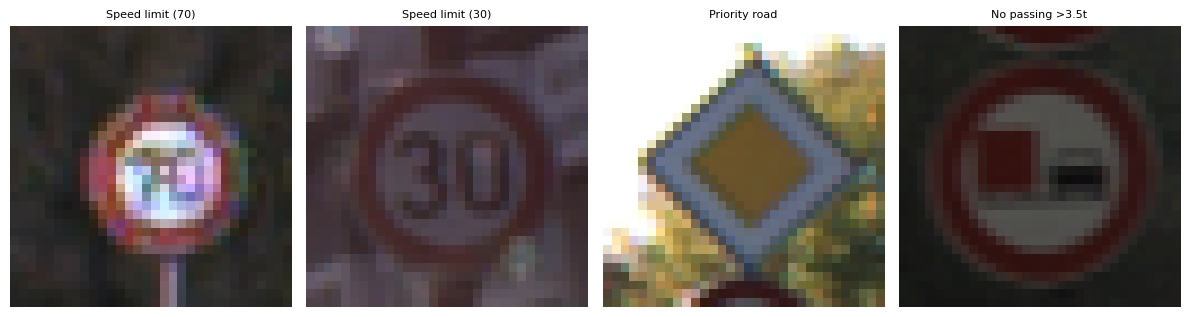

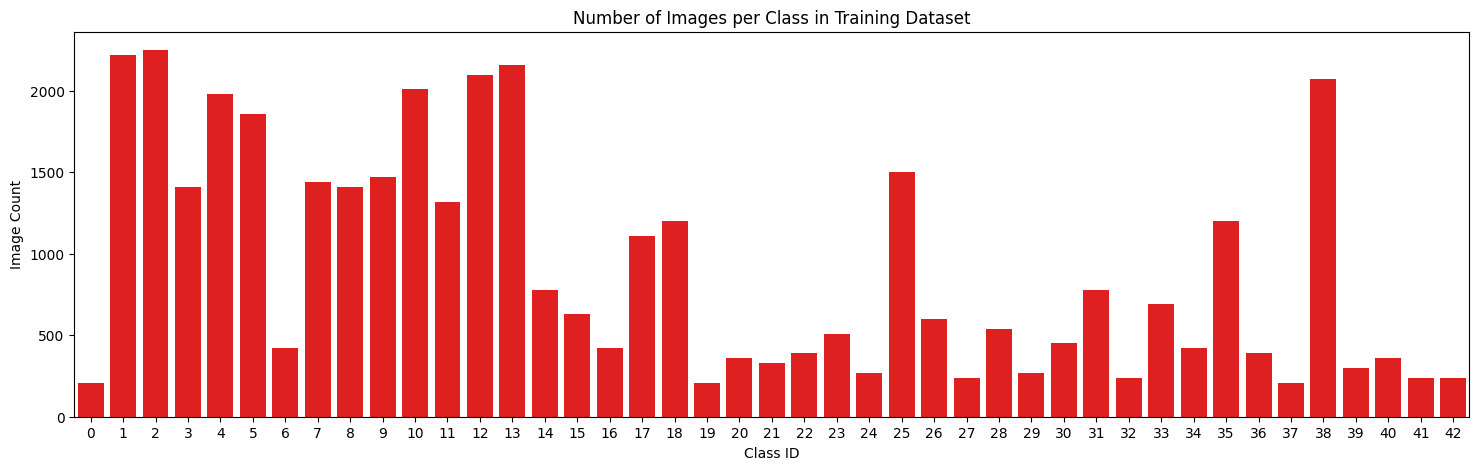

In [15]:
sample_indices = random.sample(range(len(data)), 4) #4 random images from the dataset

plt.figure(figsize=(12,4)) #4 since, it let us plot the 4 images next to each other
for plot_index, data_index in enumerate(sample_indices): #this loop through them, namely the image index and position in the plot
    plt.subplot(1, 4, plot_index + 1) #the layout is 1 row and 4 columns
    plt.imshow(data[data_index])
    plt.title(class_names[int(labels[data_index])], fontsize=8)
    plt.axis('off')

plt.tight_layout() #this makes it cleaner
plt.show()

class_count_df = pd.Series(labels).value_counts().sort_index().reset_index() #converts into pdm counts themm sort them and turns it into df
class_count_df.columns = ['ClassId', 'Image Count'] #only for readability of the names
#teh bar ploting code
plt.figure(figsize=(18,5))
sns.barplot(data=class_count_df, x='ClassId', y='Image Count', color='red')
plt.title('Number of Images per Class in Training Dataset')
plt.xlabel('Class ID')
plt.ylabel('Image Count')
plt.show()

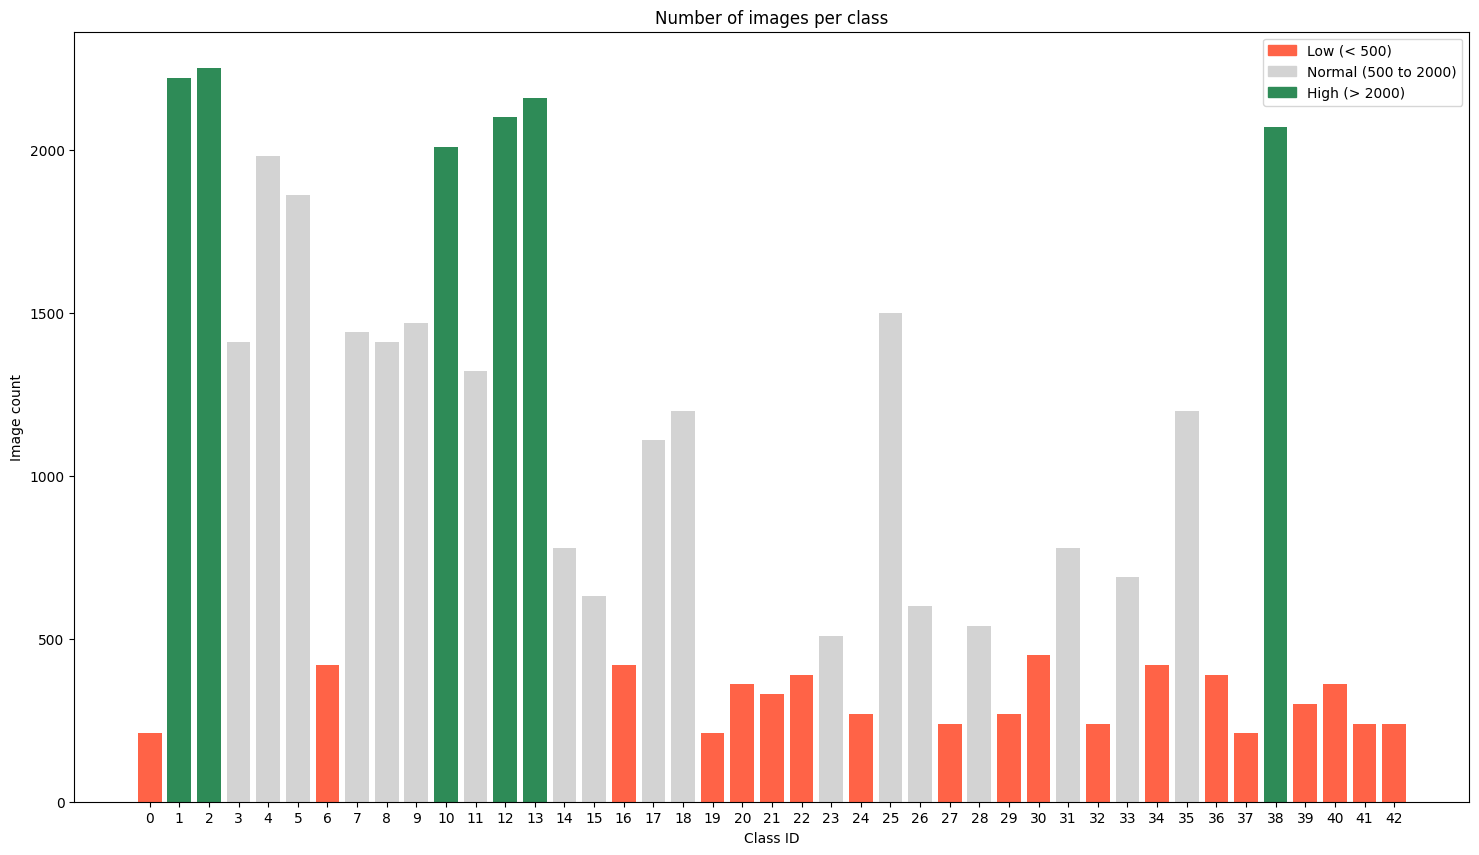

Low classes (<500 images):
    ClassId  Image Count
0         0          210
19       19          210
37       37          210
27       27          240
32       32          240
41       41          240
42       42          240
29       29          270
24       24          270
39       39          300
21       21          330
20       20          360
40       40          360
22       22          390
36       36          390
6         6          420
16       16          420
34       34          420
30       30          450

High classes (>2000 images):
    ClassId  Image Count
10       10         2010
38       38         2070
12       12         2100
13       13         2160
1         1         2220
2         2         2250


In [16]:
# a function that set thresholds
def get_class_group(count):
    if count < 500:
        return 'Low'
    elif count > 2000:
        return 'High'
    else:
        return 'Normal'


class_count_df['Group'] = class_count_df['Image Count'].apply(get_class_group)# this applies the function to the Image Count
 #the colors for the graph
color_map = {
    'Low': 'tomato',
    'High': 'seagreen',
    'Normal': 'lightgrey'
}

bar_colors = class_count_df['Group'].map(color_map) #converts each group label into its color

plt.figure(figsize=(18,10)) #height bigger than before
plt.bar(class_count_df['ClassId'], class_count_df['Image Count'], color=bar_colors)
plt.title('Number of images per class')
plt.xlabel('Class ID')
plt.ylabel('Image count')
plt.xticks(class_count_df['ClassId'])

#this creates the legend, only for visually scope and for graph readability
from matplotlib.patches import Patch
legend_items = [
    Patch(color='tomato', label='Low (< 500)'),
    Patch(color='lightgrey', label='Normal (500 to 2000)'),
    Patch(color='seagreen', label='High (> 2000)')
]
plt.legend(handles=legend_items)#this adds the legend to the chart

plt.show()

#this shows all the classes(thier ClassID and Image Count) with below 500 entries sorted
print("Low classes (<500 images):")
print(class_count_df[class_count_df['Group'] == 'Low'][['ClassId', 'Image Count']].sort_values('Image Count', ascending=True))

#this shows the ones(thier ClassID and Image Count) with over 2000 entries sorted
print("\nHigh classes (>2000 images):")
print(
    class_count_df[class_count_df['Group'] == 'High'][['ClassId', 'Image Count']].sort_values('Image Count', ascending=True))


We calculate the relative frequency

In [17]:
class_count_df['Relative Frequency'] = class_count_df['Image Count'] / class_count_df['Image Count'].sum()


We plot it

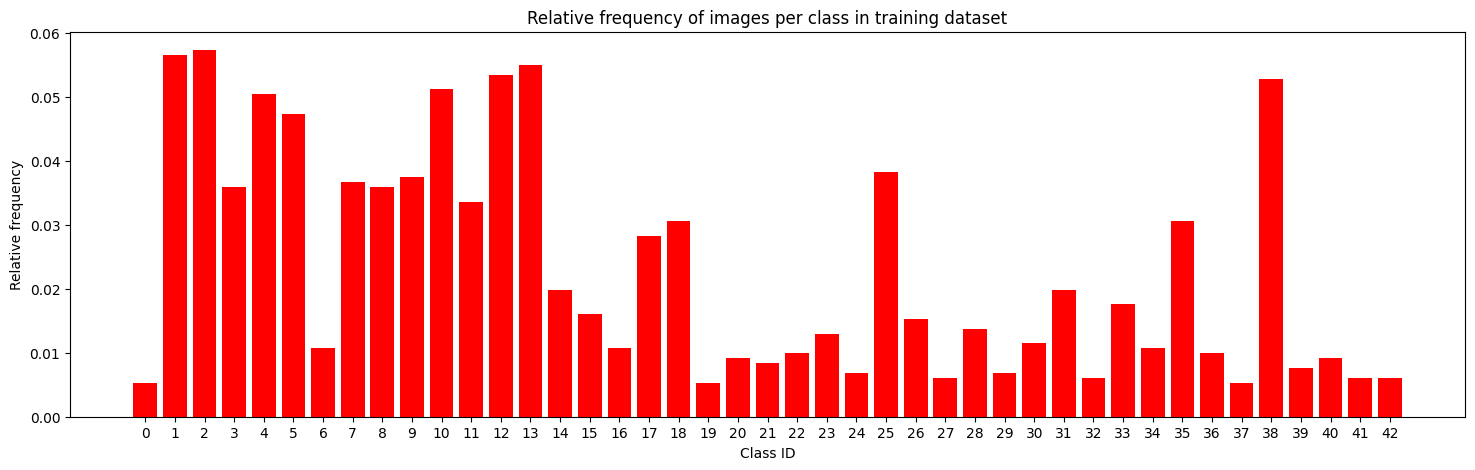

In [18]:
plt.figure(figsize=(18,5))
plt.bar(class_count_df['ClassId'], class_count_df['Relative Frequency'], color='red')
plt.title('Relative frequency of images per class in training dataset')
plt.xlabel('Class ID')
plt.ylabel('Relative frequency')
plt.xticks(class_count_df['ClassId'])
plt.show()


The data seems pretty realistic which is a very good sign

we check for the missing values

In [19]:
print("Any missing in data?", np.isnan(data).any()) #this checks if the classes have missing images
print("Any missing in labels?", np.isnan(labels).any()) #this checks if the classes have missing values

Any missing in data? False
Any missing in labels? False


we check for the dublicate values and if there are conflict of image and its label

In [20]:
import hashlib # creates uniwue fingerprints for each image
from collections import defaultdict


duplicate_groups = defaultdict(list)  # this creates an empty dictionary

for idx, img in enumerate(data):  # this loops through data
    image_hash = hashlib.md5(img.tobytes()).hexdigest()  # this creates fingerprints for each image
    duplicate_groups[image_hash].append(idx)  # this stores the current image in the dictionary under its hash

duplicates = [idxs for idxs in duplicate_groups.values() if len(idxs) > 1]  # this creates a list with the duplicate groups
print(f"Number of duplicate groups: {len(duplicates)}")
print(f"Total duplicated images: {sum(len(g) for g in duplicates)}")

conflicts = 0
for idxs in duplicates:  # this loops through duplicate groups
    unique_labels = set(labels[idxs])
    if len(unique_labels) > 1:
        conflicts += 1
        print(f"Identical images have labels: {sorted(unique_labels)} at indices {idxs}")

print(f"\nDuplicate groups with conflicting labels: {conflicts}")



Number of duplicate groups: 0
Total duplicated images: 0

Duplicate groups with conflicting labels: 0


In [21]:
import hashlib # creates uniwue fingerprints for each image
from collections import defaultdict

duplicate_groups = defaultdict(list) #this creates an empty dictionatry

for idx, img in enumerate(data): #loops throughout the data
    img_hash = hashlib.md5(img.tobytes()).hexdigest()
    duplicate_groups[img_hash].append(idx)

duplicate_groups = {h: idxs for h, idxs in duplicate_groups.items() if len(idxs) > 1}

print("Number of duplicate groups:", len(duplicate_groups))
print("Number of duplicated images:", sum(len(idxs) for idxs in duplicate_groups.values()))

duplicate_rows = []
for group_id, (img_hash, idxs) in enumerate(duplicate_groups.items(), start=1):
    group_labels = labels[idxs]
    duplicate_rows.append({
        "Group": group_id,
        "Indices": idxs,
        "Count": len(idxs),
        "Labels": list(group_labels),
        "Same label": len(set(group_labels)) == 1
    })

duplicates_df = pd.DataFrame(duplicate_rows)
duplicates_df


Number of duplicate groups: 0
Number of duplicated images: 0


""


We verify the pixels value

In [22]:
print("Min pixel value:", data.min())
print("Max pixel value:", data.max())

Min pixel value: 0
Max pixel value: 255


Preparing the Dataset

We convert the images into arrays, normalise them and encode the labels before training the model.


In [23]:
def prep_dataset(X,y): #X-is the images and y is the labels
    X_prep = X.astype('float32') / 255.0  #converts X to float and scale the pixel values from 0-255 to 0-1
    y_prep = to_categorical(np.array(y)) #encodes the class lables into one-hot encoded vectors
    return (X_prep, y_prep)

X, y = prep_dataset(data,labels)

brightness of the images

Minimum brightness: 6.63671875
Maximum brightness: 247.49153645833334
Average brightness: 82.71219236043808


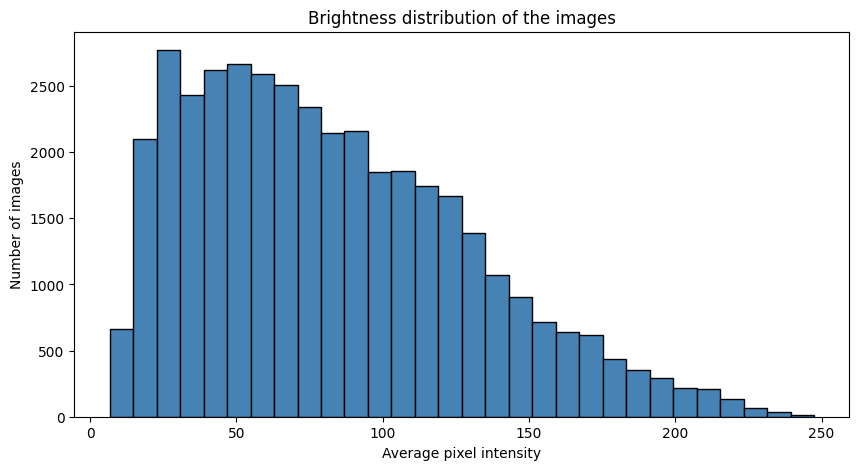

In [24]:
brightness = data.mean(axis=(1, 2, 3))# average brightness per image


print("Minimum brightness:", brightness.min()) #the minimum
print("Maximum brightness:", brightness.max()) #the maximum
print("Average brightness:", brightness.mean()) #the average

plt.figure(figsize=(10,5))
plt.hist(brightness, bins=30, color='steelblue', edgecolor='black')
plt.title('Brightness distribution of the images')
plt.xlabel('Average pixel intensity')
plt.ylabel('Number of images')
plt.show()

This code help us visualise the brightest and darkest images

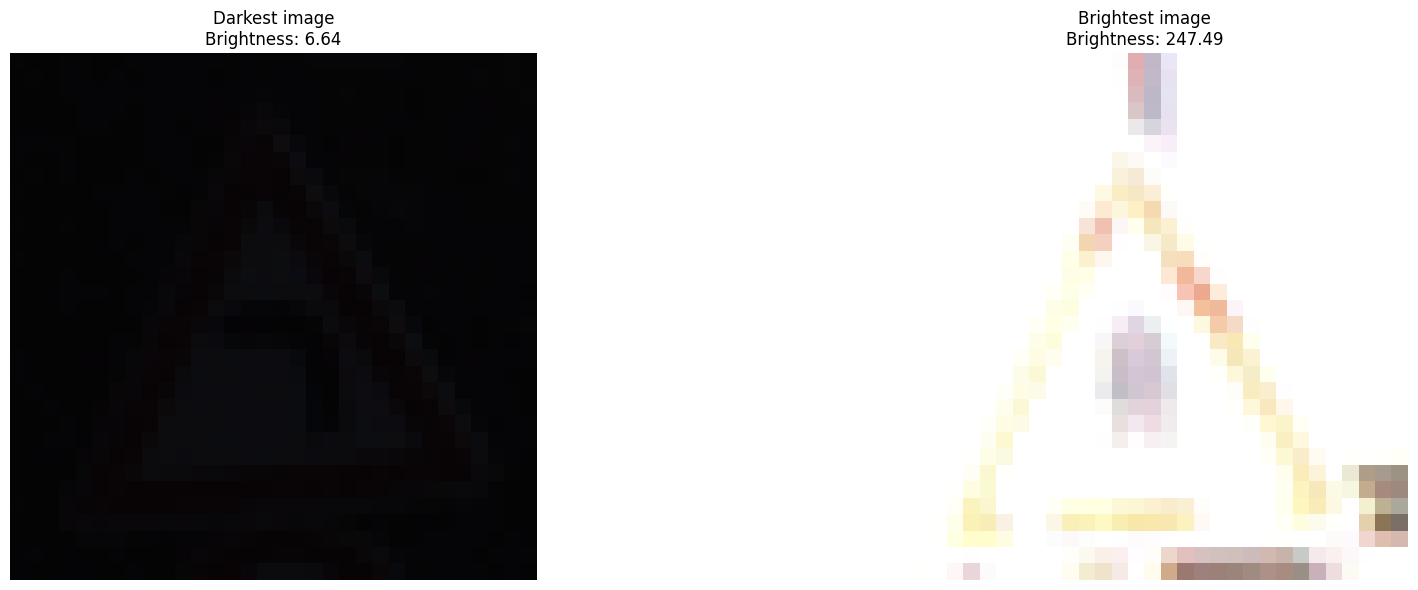

In [25]:
darkest_i = np.argmin(brightness) # this finds the index of the image with the smallest brightness value
brightest_i= np.argmax(brightness) #This does the samem but for the highest brightness value

plt.figure(figsize=(20,6))

#this plot the darkest image
plt.subplot(1,2,1) #the first is for row, the second is the columns and teh third is the position
plt.imshow(data[darkest_i])
plt.title(f'Darkest image\nBrightness: {brightness[darkest_i]:.2f}')
plt.axis('off') #this helps us to see teh iamges better without the coordinates

#this plot the brightness image
plt.subplot(1,2,2)
plt.imshow(data[brightest_i])
plt.title(f'Brightest image\nBrightness: {brightness[brightest_i]:.2f}')
plt.axis('off') #this helps us to see teh iamges better without the coordinates

plt.tight_layout()
plt.show()


This may be a problem for the datsetm since this images you cannot distiguised nothing and can affect the performance of the model

The next problem that I want to address is how many of this images arem we want to get all the pictures over 200 and below 50

In [26]:
too_dark = np.where(brightness < 50)[0] #count the images below 50 brightness
too_bright = np.where(brightness > 200)[0] #count the images above 200 brightness

print("Very dark images:", len(too_dark))
print("Very bright images:", len(too_bright))


Very dark images: 11691
Very bright images: 655


the solution to the previous problem

In [27]:
data_augmentation = tf.keras.Sequential([
    layers.RandomBrightness(factor=0.15, value_range=(0, 1)), #this adds random brightness by making it brighter or darker and they can vary by 15%, the values range is given to tell Keras that the values are normalised already
    layers.RandomContrast(factor=0.15) #this does the same thingm but with contrast
], name='data_augmentation') # this gives its name


Splitting the dataset

We split the data into training, validation and test sets.


In [28]:
X_train, X_val, Y_train, Y_val, labels_train, labels_val = train_test_split(X, y, labels, test_size=0.30, shuffle=True, stratify=labels, random_state=seed_value)# the split of the data between train 70% and test 30%, shuffled.
X_val, X_test, Y_val, Y_test, labels_val, labels_test = train_test_split(X_val, Y_val, labels_val, test_size=0.5, shuffle=True, stratify=labels_val, random_state=seed_value) #the split of the validation 50% and the test 50% out of the previous test

**CNN Model**

First arhitecture

In [29]:
reset_everything(seed_value)# to not let the model performance depend on already learned weights and to make the two performances comparable


model1 = models.Sequential() #a sequential neural network

model1.add(layers.Input(shape=X.shape[1:]))
model1.add(data_augmentation) #augmented data

# Block 1
#ConvLayer(64 filters) + MaxPooling + BatchNormalization + Dropout
model1.add(layers.Conv2D(filters=32,kernel_size=3,activation='relu',padding='same'))
model1.add(layers.MaxPool2D(strides=2))
model1.add(layers.BatchNormalization())
model1.add(layers.Dropout(0.3))

#ConvLayer(128 filters) + MaxPooling + BatchNormalization + Dropout
model1.add(layers.Conv2D(filters=128,kernel_size=3,activation='relu',padding='same'))
model1.add(layers.MaxPool2D(strides=2))
model1.add(layers.BatchNormalization())
model1.add(layers.Dropout(0.3))

#ConvLayer(512 filters) + Dropout + ConvLayer(512 filters) + MaxPooling + BatchNormalization
model1.add(layers.Conv2D(filters=512,kernel_size=3,activation='relu',padding='same'))
model1.add(layers.Dropout(0.3))
model1.add(layers.Conv2D(filters=512,kernel_size=3,activation='relu',padding='same'))
model1.add(layers.MaxPool2D(strides=2))
model1.add(layers.BatchNormalization())

#Flatten
model1.add(layers.Flatten())

#2 Dense layers with 4000 hidden units
model1.add(layers.Dense(4000,activation='relu'))
model1.add(layers.Dense(4000,activation='relu'))

#Dense layer with 1000 hidden units
model1.add(layers.Dense(1000,activation='relu'))

#Softmax layer for output
model1.add(layers.Dense(43,activation='softmax'))

model1.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 512)      │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4000)           │    32,772,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4000)           │    16,004,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │     4,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │        43,043 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,810,763 (212.90 MB)

 Trainable params: 55,809,419 (212.90 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [30]:
model1.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])

history1= model1.fit(X_train,Y_train,
                 epochs=20,
                 batch_size=64,
                 validation_data=(X_val,Y_val))

Epoch 1/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 42s 65ms/step - accuracy: 0.5727 - loss: 1.4959 - val_accuracy: 0.3921 - val_loss: 2.4770
Epoch 2/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.9228 - loss: 0.2509 - val_accuracy: 0.9718 - val_loss: 0.1197
Epoch 3/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.9511 - loss: 0.1678 - val_accuracy: 0.9825 - val_loss: 0.0599
Epoch 4/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.9646 - loss: 0.1206 - val_accuracy: 0.9827 - val_loss: 0.0641
Epoch 5/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9655 - loss: 0.1299 - val_accuracy: 0.9878 - val_loss: 0.0507
Epoch 6/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.9686 - loss: 0.1101 - val_accuracy: 0.9827 - val_loss: 0.0759
Epoch 7/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.9713 - loss: 0.1060 - val_accuracy: 0.9910 - val_loss: 0.0392
Epoch 8/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.9707 - loss: 0.1182 - 

second arhitecture

In [31]:
reset_everything(seed_value)# to not let the model performance depend on already learned weights and to make the two performances comparable

model2 = models.Sequential()  # smaller VGG-style CNN
model2.add(layers.Input(shape=X.shape[1:]))
model2.add(data_augmentation) #augmented data
# Block 1
model2.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model2.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model2.add(layers.MaxPool2D((2, 2)))
model2.add(layers.BatchNormalization())
model2.add(layers.Dropout(0.25))

# Block 2
model2.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model2.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model2.add(layers.MaxPool2D((2, 2)))
model2.add(layers.BatchNormalization())
model2.add(layers.Dropout(0.25))

# Block 3
model2.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model2.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model2.add(layers.MaxPool2D((2, 2)))
model2.add(layers.BatchNormalization())
model2.add(layers.Dropout(0.3))

# Block 4
model2.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model2.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model2.add(layers.MaxPool2D((2, 2)))
model2.add(layers.BatchNormalization())
model2.add(layers.Dropout(0.3))

# Classifier
model2.add(layers.Flatten())
model2.add(layers.Dense(512, activation='relu'))
model2.add(layers.Dropout(0.5))
model2.add(layers.Dense(43, activation='softmax'))

model2.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,80

 Total params: 1,721,035 (6.57 MB)

 Trainable params: 1,720,075 (6.56 MB)

 Non-trainable params: 960 (3.75 KB)

Fitting the model

In [32]:
model2.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])

history2= model2.fit(X_train,Y_train,
                 epochs=20,
                 batch_size=64,
                 validation_data=(X_val,Y_val))

Epoch 1/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.3656 - loss: 2.2770 - val_accuracy: 0.4520 - val_loss: 1.6846
Epoch 2/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.8684 - loss: 0.4174 - val_accuracy: 0.9665 - val_loss: 0.1083
Epoch 3/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9394 - loss: 0.1971 - val_accuracy: 0.9867 - val_loss: 0.0459
Epoch 4/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9581 - loss: 0.1348 - val_accuracy: 0.9908 - val_loss: 0.0375
Epoch 5/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9668 - loss: 0.1135 - val_accuracy: 0.9929 - val_loss: 0.0275
Epoch 6/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9693 - loss: 0.1047 - val_accuracy: 0.9929 - val_loss: 0.0276
Epoch 7/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9752 - loss: 0.0860 - val_accuracy: 0.9883 - val_loss: 0.0426
Epoch 8/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9748 - loss: 0.0885 - val_a

Visualisation of accuracy and loss

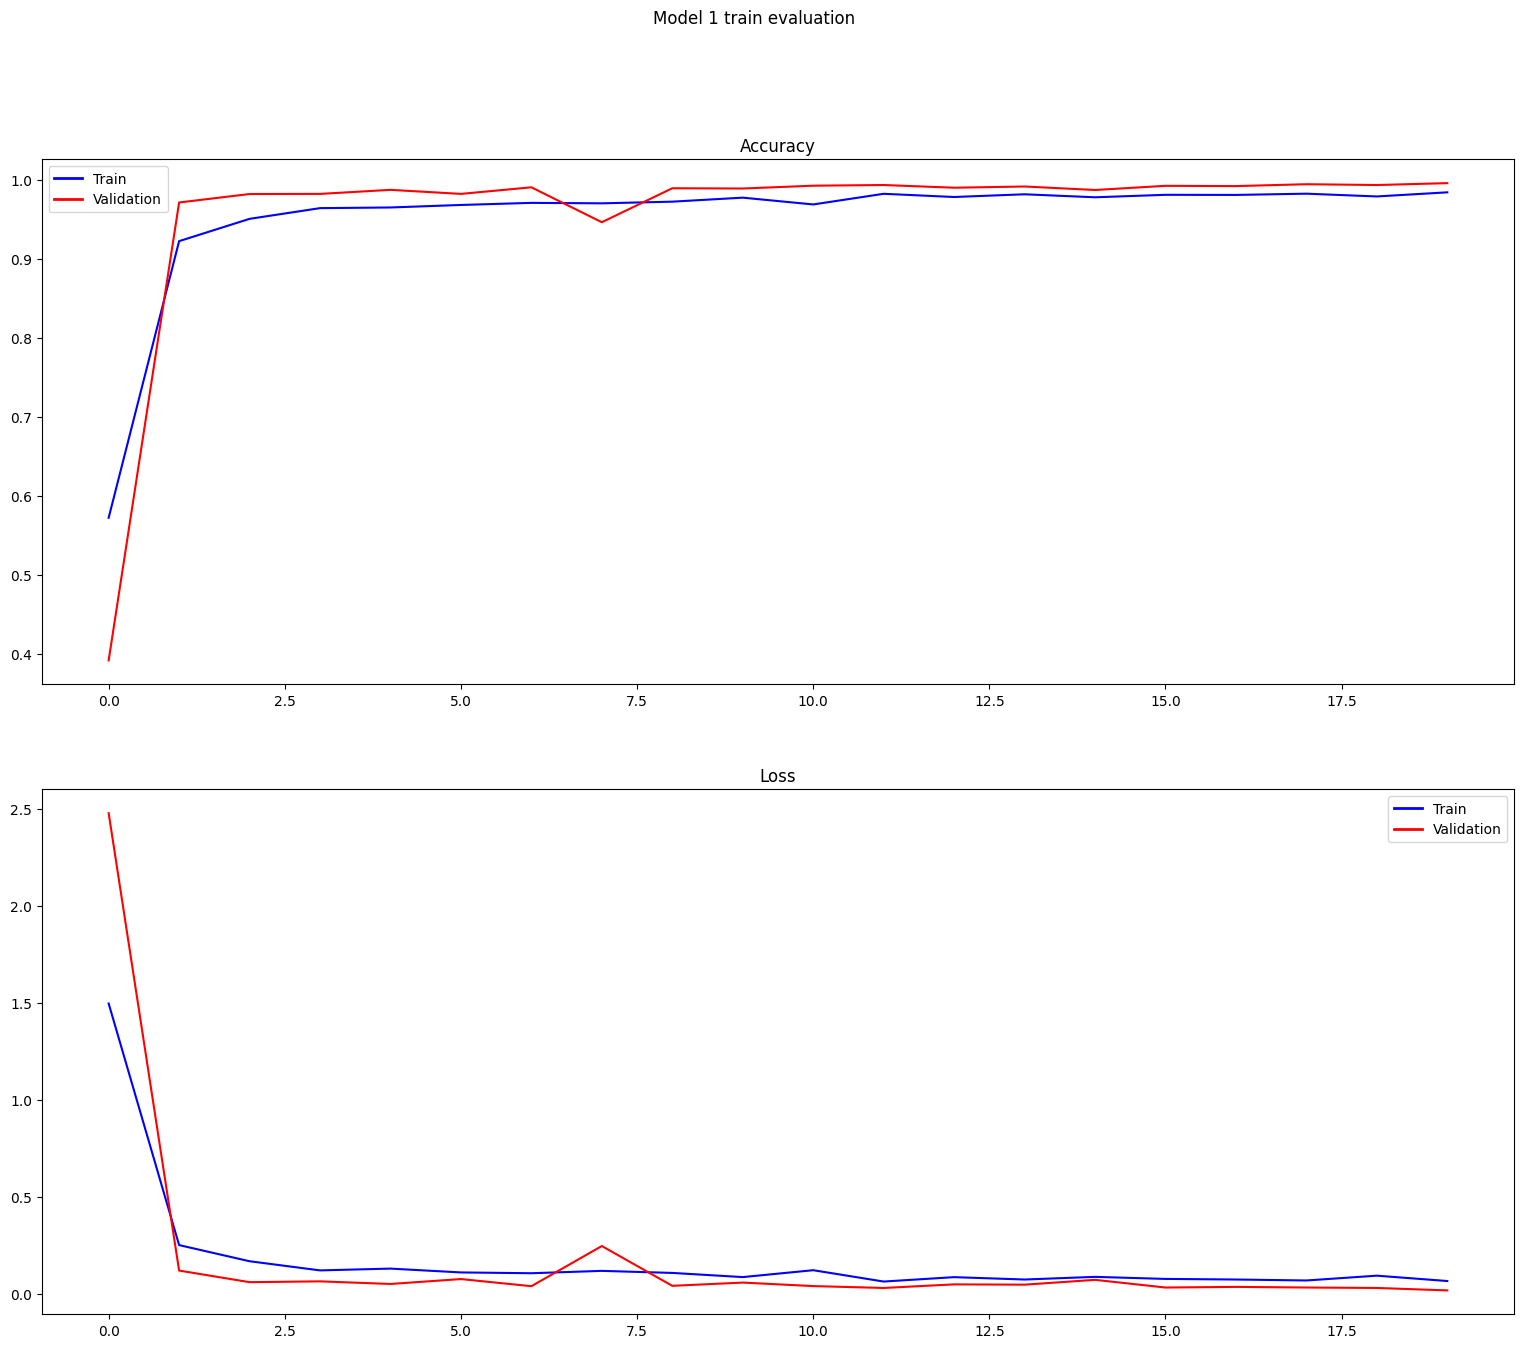

In [33]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(2, 1, figsize=(19, 15)) #the configuration with 2,1 it makes the plots one belowe other
fig.suptitle('Model 1 train evaluation')

sns.lineplot(ax=ax[0], x=np.arange(0, len(history1.history['accuracy'])), y=history1.history['accuracy'], color='blue', legend=False) #this gives the train accuracy line
sns.lineplot(ax=ax[0], x=np.arange(0, len(history1.history['val_accuracy'])), y=history1.history['val_accuracy'], color='red', legend=False) #this gives the validation accuracy line

ax[0].set_title('Accuracy')

#this is a manual legendm since the seaborn does not work correctly and instead of the red validation line it showed a box
ax[0].legend(handles=[
    Line2D([0], [0], color='blue', lw=2, label='Train'),
    Line2D([0], [0], color='red', lw=2, label='Validation')
])

#this is exactly the same as beforem but for the losses
sns.lineplot(ax=ax[1], x=np.arange(0, len(history1.history['loss'])), y=history1.history['loss'], color='blue', legend=False)
sns.lineplot(ax=ax[1], x=np.arange(0, len(history1.history['val_loss'])), y=history1.history['val_loss'], color='red', legend=False)


ax[1].set_title('Loss')
ax[1].legend(handles=[
    Line2D([0], [0], color='blue', lw=2, label='Train'),
    Line2D([0], [0], color='red', lw=2, label='Validation')
])

plt.show()




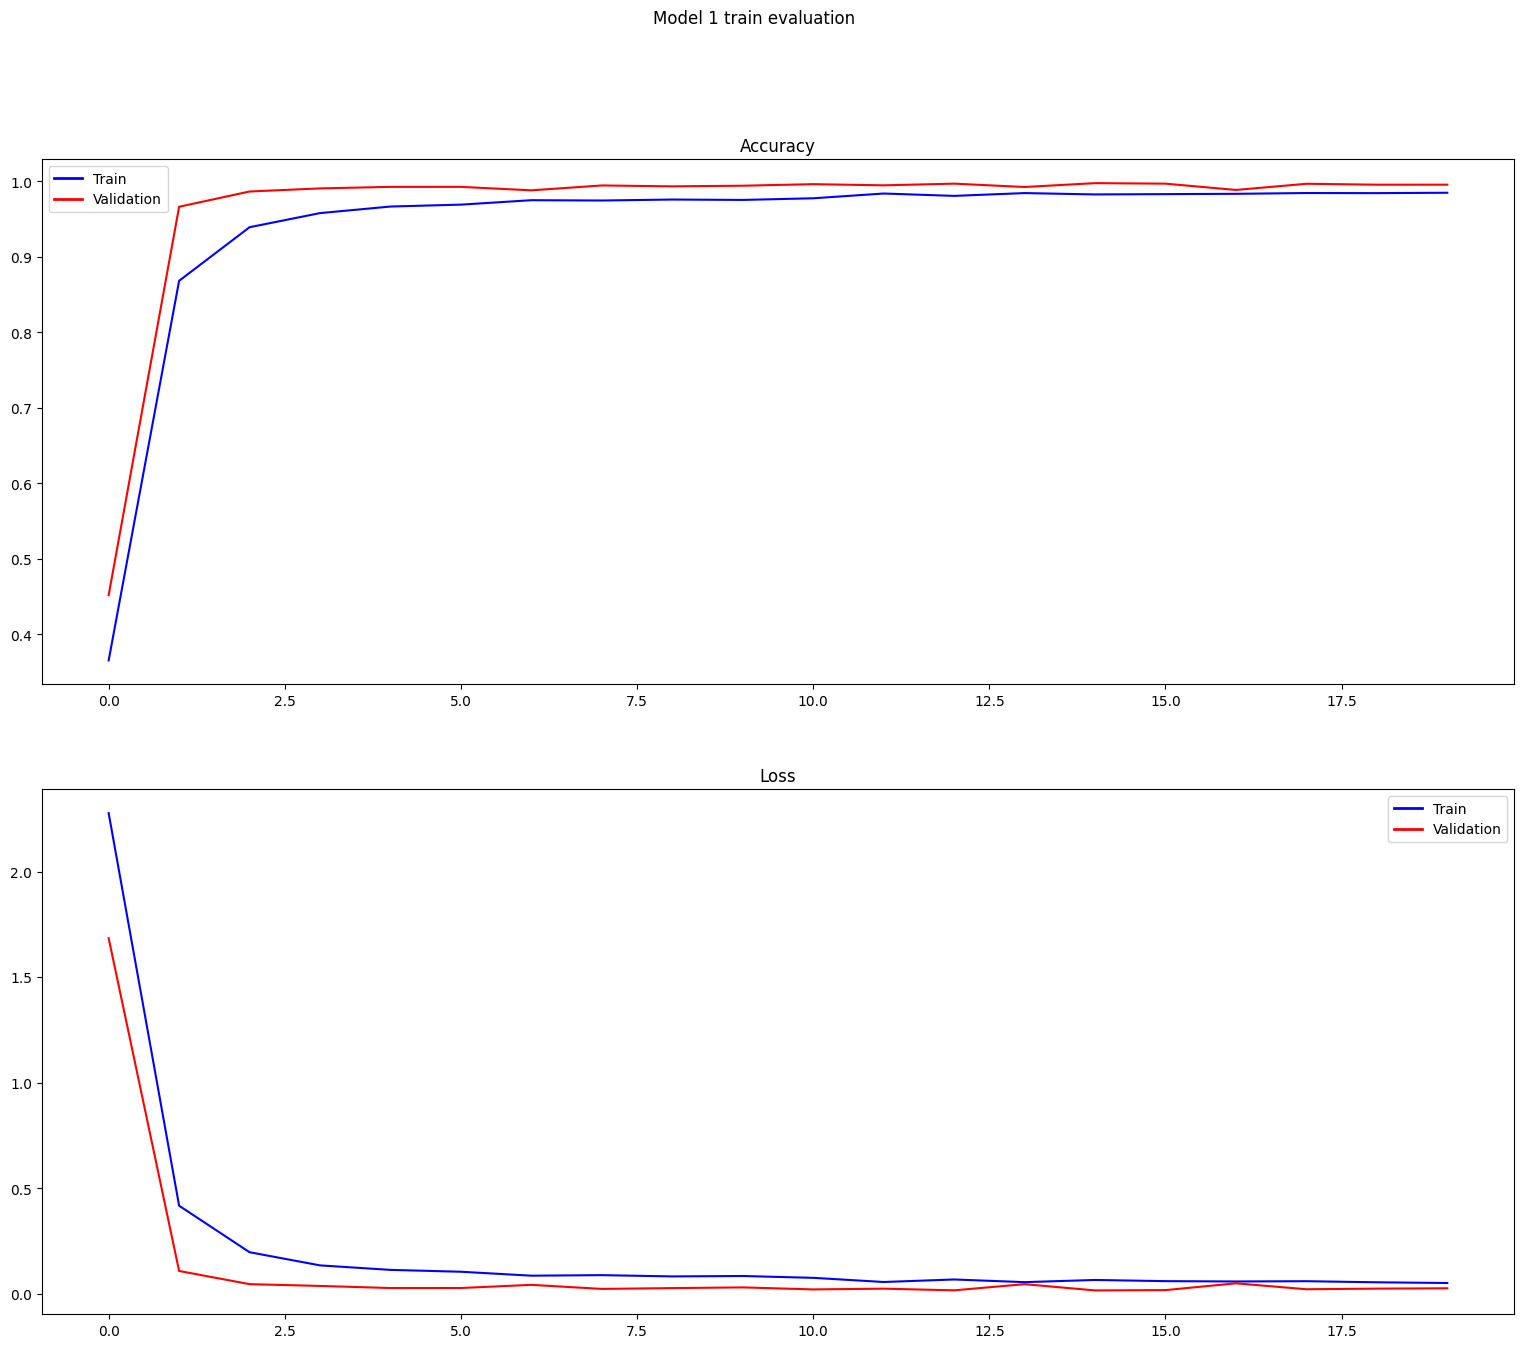

In [34]:
#this is exactly as beforem but for teh second model
from matplotlib.lines import Line2D

fig, ax = plt.subplots(2, 1, figsize=(19, 15))
fig.suptitle('Model 1 train evaluation')

sns.lineplot(ax=ax[0], x=np.arange(0, len(history2.history['accuracy'])), y=history2.history['accuracy'], color='blue', legend=False)
sns.lineplot(ax=ax[0], x=np.arange(0, len(history2.history['val_accuracy'])), y=history2.history['val_accuracy'], color='red', legend=False)

ax[0].set_title('Accuracy')
ax[0].legend(handles=[
    Line2D([0], [0], color='blue', lw=2, label='Train'),
    Line2D([0], [0], color='red', lw=2, label='Validation')
])

sns.lineplot(ax=ax[1], x=np.arange(0, len(history2.history['loss'])), y=history2.history['loss'], color='blue', legend=False)
sns.lineplot(ax=ax[1], x=np.arange(0, len(history2.history['val_loss'])), y=history2.history['val_loss'], color='red', legend=False)

ax[1].set_title('Loss')
ax[1].legend(handles=[
    Line2D([0], [0], color='blue', lw=2, label='Train'),
    Line2D([0], [0], color='red', lw=2, label='Validation')
])

plt.show()


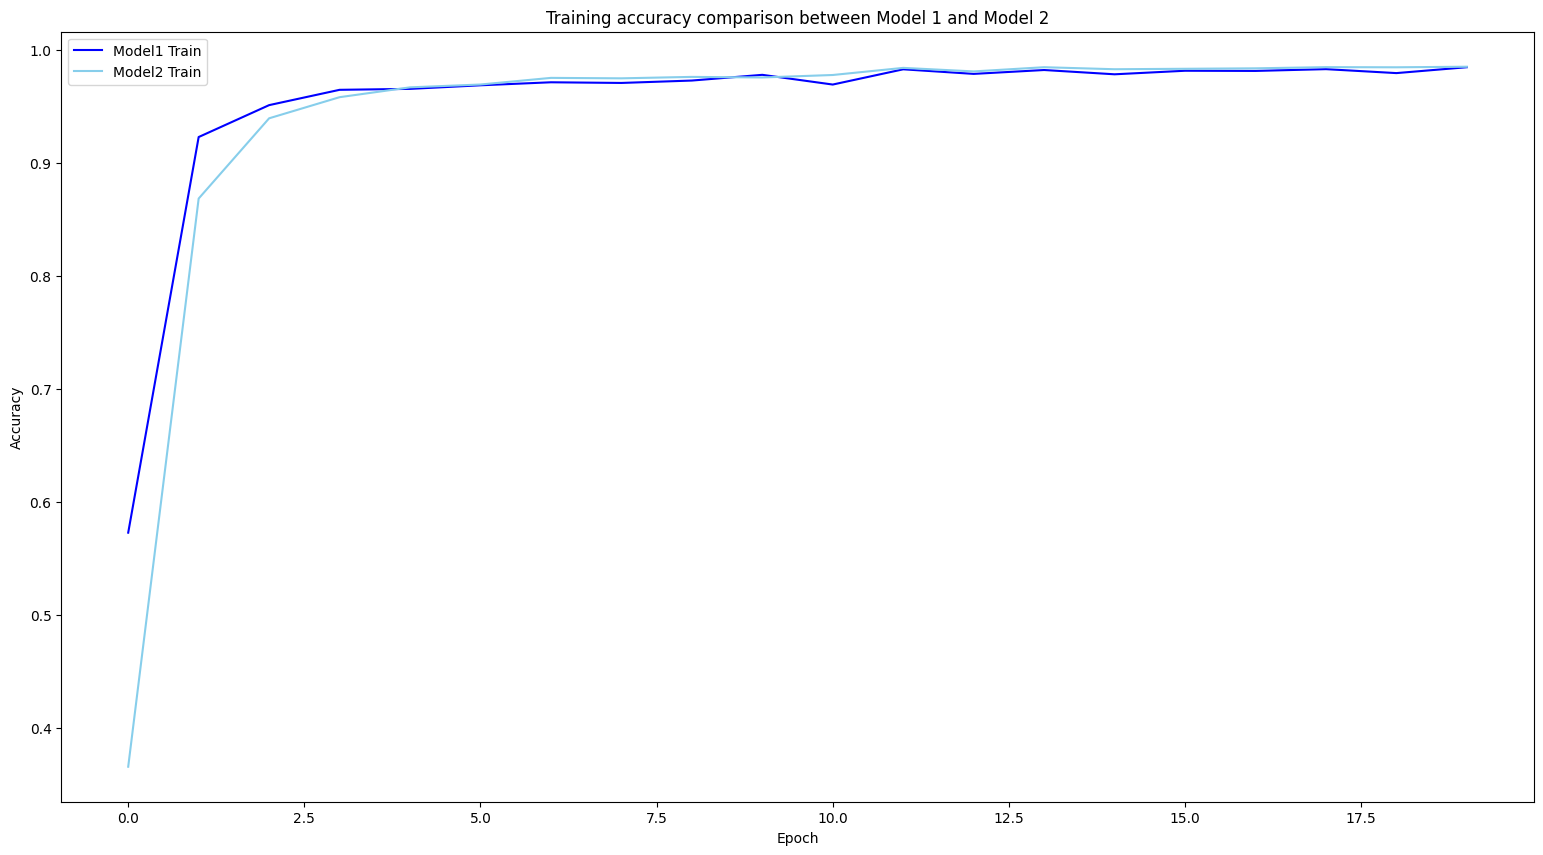

In [35]:
plt.figure(figsize=(19,10))

plt.plot(np.arange(0,len(history1.history['accuracy'])), history1.history['accuracy'], color='blue')
plt.plot(np.arange(0,len(history2.history['accuracy'])), history2.history['accuracy'], color='skyblue')

plt.title('Training accuracy comparison between Model 1 and Model 2')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Model1 Train','Model2 Train'])
plt.show()


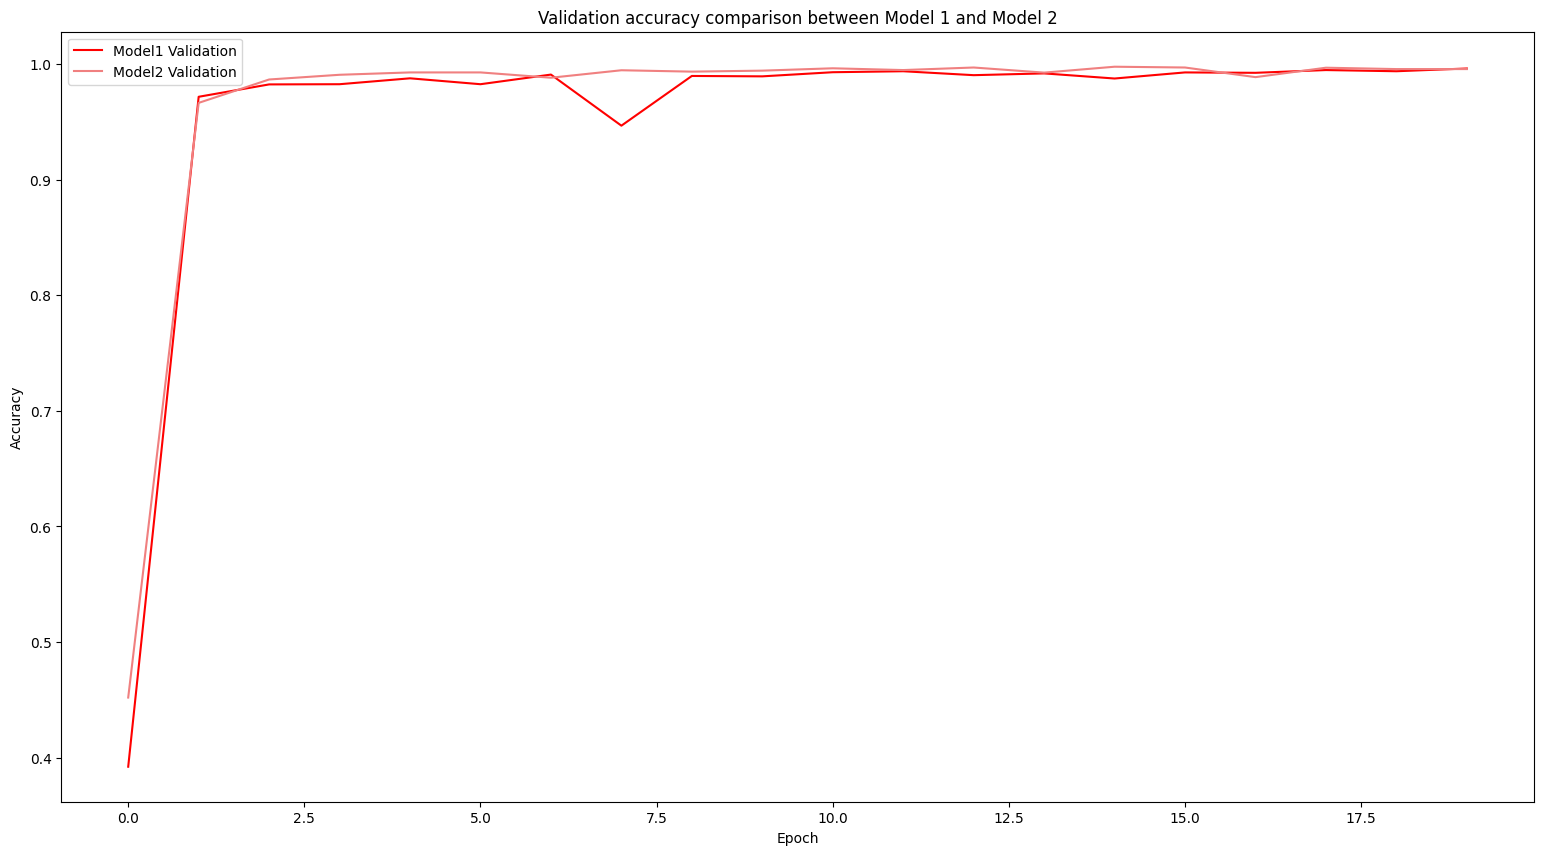

In [36]:
plt.figure(figsize=(19,10))

plt.plot(np.arange(0,len(history1.history['val_accuracy'])), history1.history['val_accuracy'], color='red')
plt.plot(np.arange(0,len(history2.history['val_accuracy'])), history2.history['val_accuracy'], color='lightcoral')

plt.title('Validation accuracy comparison between Model 1 and Model 2')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Model1 Validation','Model2 Validation'])
plt.show()


we calculated the f1 score

In [37]:
from sklearn.metrics import f1_score

y_true = np.argmax(Y_test, axis=1)
y_pred1 = np.argmax(model1.predict(X_test), axis=1)
y_pred2 = np.argmax(model2.predict(X_test), axis=1)

f1_results = pd.DataFrame({
    'Model': ['Model 1', 'Model 2'],
    'F1 Macro': [
        f1_score(y_true, y_pred1, average='macro'),
        f1_score(y_true, y_pred2, average='macro')
    ],
    #this is for class imbalance which suit best, since our dataset is very imbalanced
    'F1 Weighted': [
        f1_score(y_true, y_pred1, average='weighted'),
        f1_score(y_true, y_pred2, average='weighted')
    ]
})

f1_results


184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


,Model,F1 Macro,F1 Weighted
0,Model 1,0.996345,0.996773
1,Model 2,0.994511,0.994064


confusion matrix for the first model

In [38]:
from sklearn.metrics import confusion_matrix
y_true = np.argmax(Y_test, axis=1) #from one-hot encoding back to the class numbers
y_pred1 = np.argmax(model1.predict(X_test), axis=1)# this gets the predicted class for the test iamges

cm1 = confusion_matrix(y_true, y_pred1) #this plot the confusion matrix

cm1_df = pd.DataFrame(cm1)
cm1_df


184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,30,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,332,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,337,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,211,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,297,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,277,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,63,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,211,4,0,...,0,0,0,0,0,0,0,1,0,0
8,0,0,0,0,0,0,0,0,212,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,221,...,0,0,0,0,0,0,0,0,0,0


confusion matrix for the second model

In [39]:
#this code does exactly the same, but for the second model
y_pred2 = np.argmax(model2.predict(X_test), axis=1)

cm2 = confusion_matrix(y_true, y_pred2)

cm2_df = pd.DataFrame(cm2)
cm2_df


184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,30,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,323,1,0,1,3,0,1,2,0,...,1,0,0,0,0,0,0,0,0,0
2,0,0,337,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,210,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,297,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,277,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,63,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,216,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,1,0,0,0,0,0,211,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,219,...,0,0,0,0,0,0,0,0,0,0


The table with the actual class namem with the predicted class name and how many it happened for the first model

In [40]:
wrong_predictions_1 = []

for actual_class in range(cm1.shape[0]): #this loops through all rows of confusion matrix
    for predicted_class in range(cm1.shape[1]): #this loop through all the columns of the confusion matrix
        count = cm1[actual_class, predicted_class] #this counts how many time actual class was predicted class

        if actual_class != predicted_class and count > 0: #keep only the wrong one
            #this are the printing
            wrong_predictions_1.append({
                'Actual Class Name': class_names[actual_class],
                'Predicted Class Name': class_names[predicted_class],
                'Count': count
            })

wrong_df_1 = pd.DataFrame(wrong_predictions_1).sort_values('Count', ascending=False)
wrong_df_1



,Actual Class Name,Predicted Class Name,Count
6,Speed limit (100),Speed limit (120),4
0,Speed limit (20),Speed limit (30),1
2,Speed limit (50),Speed limit (30),1
1,Speed limit (30),Yield,1
3,Speed limit (60),Speed limit (80),1
4,Speed limit (80),End speed limit(80),1
5,Speed limit (80),Speed limit (100),1
7,Speed limit (100),Roundabout,1
8,No passing >3.5t,Speed limit (80),1
9,Danger curve right,Speed limit (70),1


This is only to see all the table

In [41]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

wrong_df_1


,Actual Class Name,Predicted Class Name,Count
6,Speed limit (100),Speed limit (120),4
0,Speed limit (20),Speed limit (30),1
2,Speed limit (50),Speed limit (30),1
1,Speed limit (30),Yield,1
3,Speed limit (60),Speed limit (80),1
4,Speed limit (80),End speed limit(80),1
5,Speed limit (80),Speed limit (100),1
7,Speed limit (100),Roundabout,1
8,No passing >3.5t,Speed limit (80),1
9,Danger curve right,Speed limit (70),1


In [42]:
wrong_by_actual_class = wrong_df_1.groupby('Actual Class Name')['Count'].sum().sort_values(ascending=False)
wrong_by_actual_class


,Count
Actual Class Name,
Speed limit (100),5
Speed limit (80),2
Keep right,2
Ahead only,1
Children crossing,1
End no passing >3.5t,1
Danger curve right,1
Speed limit (20),1
No passing >3.5t,1


The table with the actual class namem with the predicted class name and how many it happened for the first model

In [43]:
wrong_predictions_2 = []

for actual_class in range(cm2.shape[0]):
    for predicted_class in range(cm2.shape[1]):
        count = cm2[actual_class, predicted_class]

        if actual_class != predicted_class and count > 0:
            wrong_predictions_2.append({
                'Actual Class Name': class_names[actual_class],
                'Predicted Class Name': class_names[predicted_class],
                'Count': count
            })

wrong_df_2 = pd.DataFrame(wrong_predictions_2).sort_values('Count', ascending=False)
wrong_df_2


,Actual Class Name,Predicted Class Name,Count
18,Road work,Wild animals,7
3,Speed limit (30),Speed limit (80),3
5,Speed limit (30),Speed limit (120),2
13,No passing,No passing >3.5t,2
16,General caution,Wild animals,2
9,Speed limit (60),Speed limit (80),2
0,Speed limit (20),Speed limit (120),1
6,Speed limit (30),Yield,1
4,Speed limit (30),Speed limit (100),1
1,Speed limit (30),Speed limit (50),1


In [44]:
wrong_by_actual_class2 = wrong_df_2.groupby('Actual Class Name')['Count'].sum().sort_values(ascending=False)
wrong_by_actual_class2

,Count
Actual Class Name,
Speed limit (30),10
Road work,7
No passing,2
General caution,2
Speed limit (80),2
Speed limit (60),2
Bicycles crossing,1
Danger curve right,1
No vehicles,1


The functions to calculate the time of the two models

In [45]:
import time
from tensorflow.keras.callbacks import Callback

class TimeHistory(Callback): # the parent class is the import from the above
    def on_train_begin(self, logs=None):
        self.epoch_times = [] #this will store each epoch time
        self.train_start = time.time() #this store the exact time of starting the training

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time() #this stores the time when each epoch starts

    def on_epoch_end(self, epoch, logs=None): #this is called after each epochs end
        self.epoch_times.append(time.time() - self.epoch_start)  #this substract the current time from the starting time

    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.train_start # this does the same thing, but for the total


This run again the models and it measure, their time also

In [46]:
timer1 = TimeHistory() #this is the class we created above
history1 = model1.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, Y_val),
    callbacks=[timer1]
)

timer2 = TimeHistory()
history2 = model2.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, Y_val),
    callbacks=[timer2]
)


Epoch 1/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.9868 - loss: 0.0527 - val_accuracy: 0.9951 - val_loss: 0.0243
Epoch 2/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9821 - loss: 0.0845 - val_accuracy: 0.9922 - val_loss: 0.0344
Epoch 3/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9852 - loss: 0.0676 - val_accuracy: 0.9867 - val_loss: 0.0964
Epoch 4/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.9831 - loss: 0.0725 - val_accuracy: 0.9923 - val_loss: 0.0390
Epoch 5/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9873 - loss: 0.0621 - val_accuracy: 0.9932 - val_loss: 0.0318
Epoch 6/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.9854 - loss: 0.0621 - val_accuracy: 0.9951 - val_loss: 0.0364
Epoch 7/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9828 - loss: 0.0823 - val_accuracy: 0.9935 - val_loss: 0.0320
Epoch 8/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.9862 - loss: 0.0501 - 

In [47]:
comparison_df = pd.DataFrame({
    'Model': ['Model 1', 'Model 2'], #these are the models name
    'Parameters': [model1.count_params(), model2.count_params()], #how much paarmeters each has
    'Total Training Time (s)': [timer1.total_time, timer2.total_time], #calculates the total time
    'Average Epoch Time (s)': [sum(timer1.epoch_times) / len(timer1.epoch_times), #calculates the total time
                               sum(timer2.epoch_times) / len(timer2.epoch_times)], #calcultaes the epochs time
    'Final Val Accuracy': [history1.history['val_accuracy'][-1], #this -1 takes only the last validation
                           history2.history['val_accuracy'][-1]]
})


We plot now what we did above

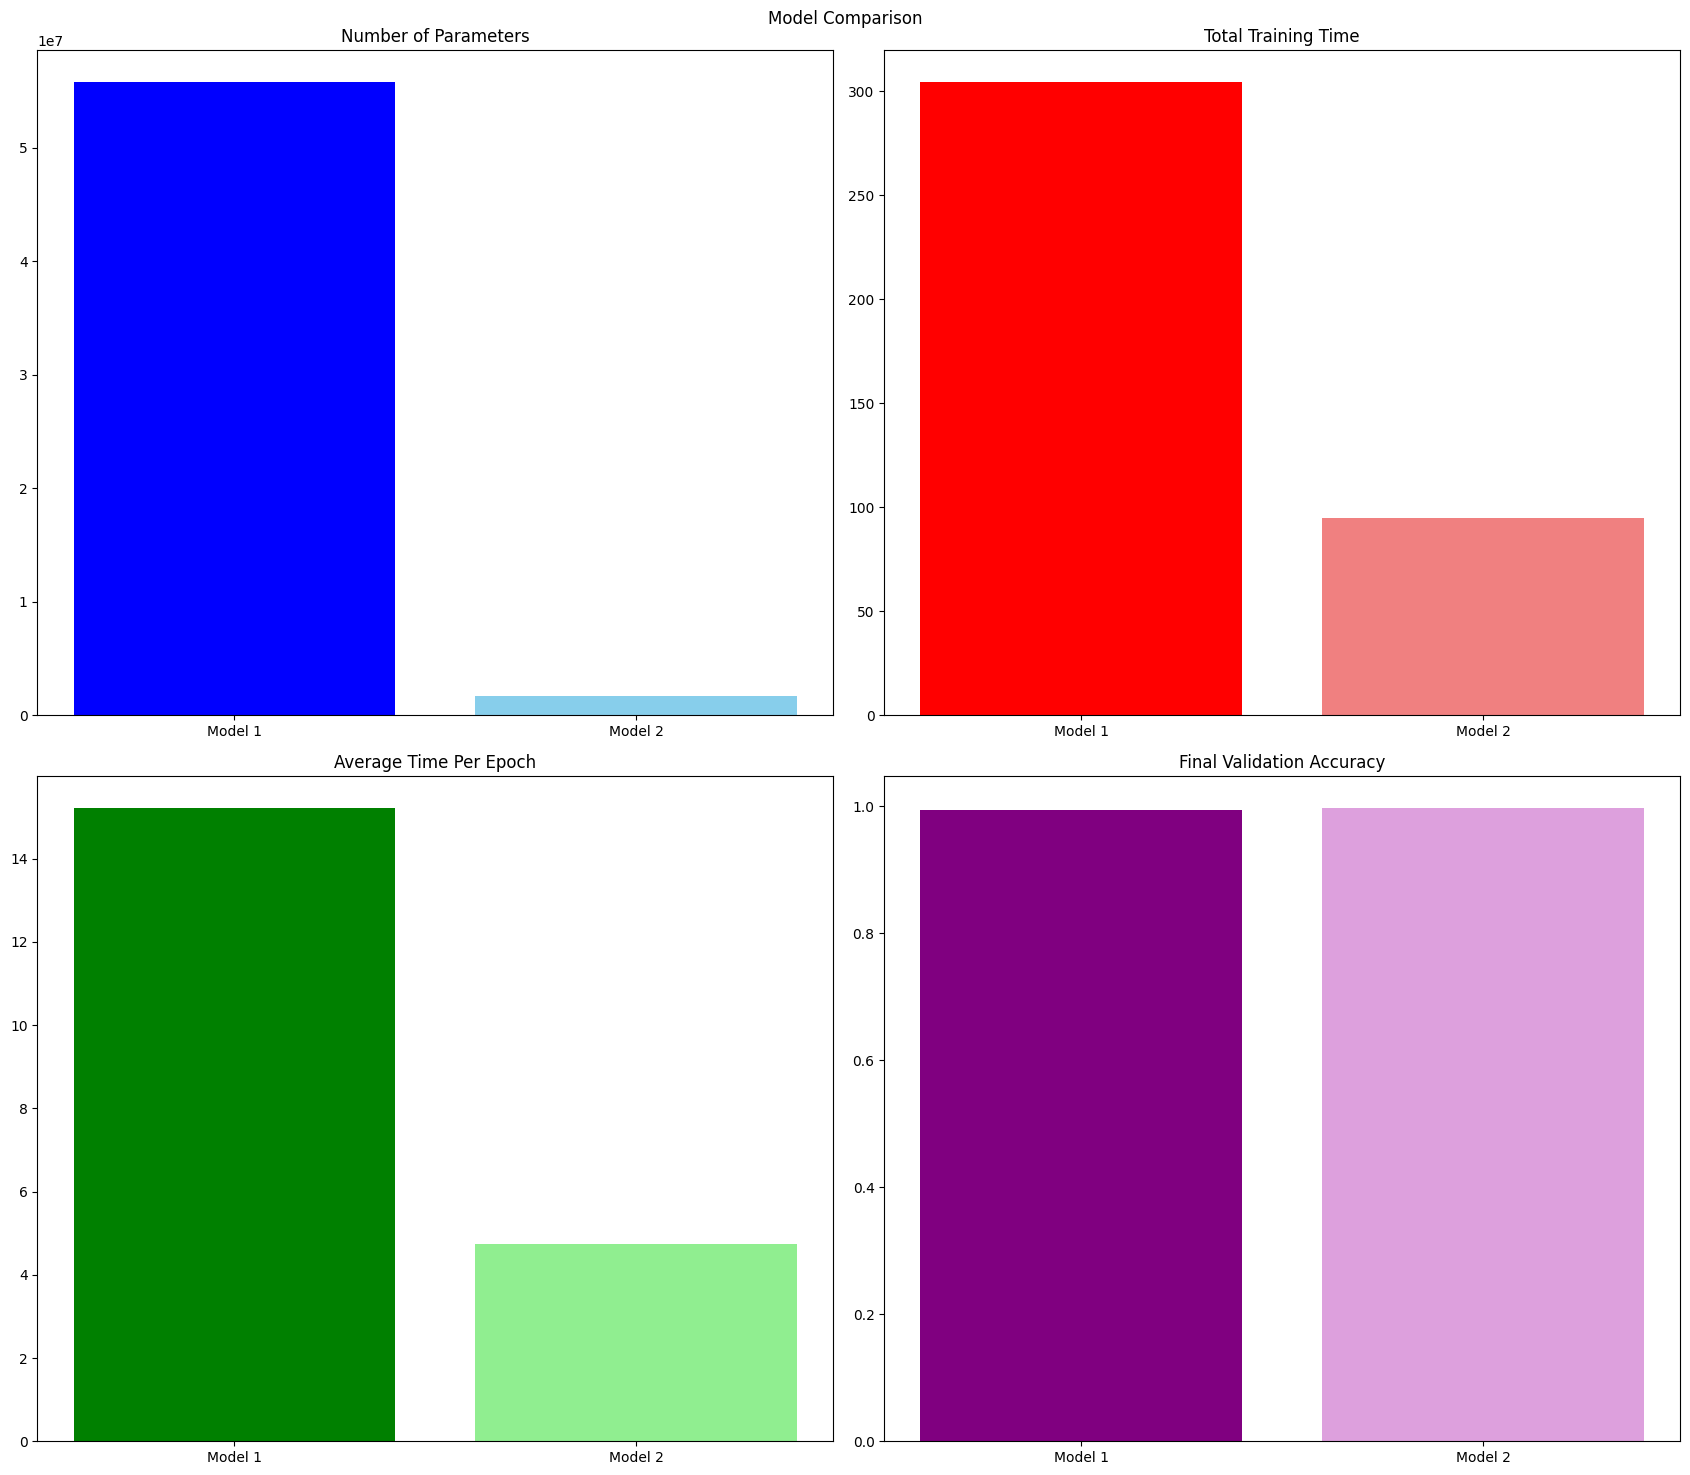

In [48]:
fig, ax = plt.subplots(2, 2, figsize=(17, 15))
fig.suptitle('Model Comparison')

#this creates a bar plot for total parameters of each model
ax[0,0].bar(comparison_df['Model'], comparison_df['Parameters'], color=['blue', 'skyblue'])
ax[0,0].set_title('Number of Parameters')

#this creates a bar plot for total training time of each model
ax[0,1].bar(comparison_df['Model'], comparison_df['Total Training Time (s)'], color=['red', 'lightcoral'])
ax[0,1].set_title('Total Training Time')

#this creates a bar plot for average epochs time of each model
ax[1,0].bar(comparison_df['Model'], comparison_df['Average Epoch Time (s)'], color=['green', 'lightgreen'])
ax[1,0].set_title('Average Time Per Epoch')

#this craetes a bar plot for final validation of each model
ax[1,1].bar(comparison_df['Model'], comparison_df['Final Val Accuracy'], color=['purple', 'plum'])
ax[1,1].set_title('Final Validation Accuracy')

plt.tight_layout()
plt.show()


relative parameters and time to Model 1

In [49]:
comparison_df['Parameters Relative to Model 1'] = comparison_df['Parameters'] / comparison_df['Parameters'][0]
comparison_df['Training Time Relative to Model 1'] = comparison_df['Total Training Time (s)'] / comparison_df['Total Training Time (s)'][0]

comparison_df



,Model,Parameters,Total Training Time (s),Average Epoch Time (s),Final Val Accuracy,Parameters Relative to Model 1,Training Time Relative to Model 1
0,Model 1,55810763,304.403352,15.216254,0.994389,1.000000,1.000000
1,Model 2,1721035,94.891960,4.741721,0.997619,0.030837,0.311731


In [50]:
param_diff = model1.count_params() - model2.count_params() #thsi calculates how much more parameters does model 1 has in comparison with model 2
time_diff = timer1.total_time - timer2.total_time # this calculates how much time does model 1 has run for compared with model 2
acc_diff = history1.history['val_accuracy'][-1] - history2.history['val_accuracy'][-1] # this calculates the how much more accurcay model 1 has over model 2

#these prints them, I put in () how was that calculated for simple understanding
print("Parameter difference (Model1 - Model2):", param_diff)
print("Total training time difference in seconds (Model1 - Model2):", round(time_diff, 2))
print("Final validation accuracy difference (Model1 - Model2):", round(acc_diff, 4))


Parameter difference (Model1 - Model2): 54089728
Total training time difference in seconds (Model1 - Model2): 209.51
Final validation accuracy difference (Model1 - Model2): -0.0032


Prediction and Evaluation

Here we use accuracy, classification report, confusion matrix and some class-wise plots to check the performance of the model.


Preparation of true and predicted labels for first Model

In [55]:
y_test_true = np.argmax(Y_test, axis=1) if len(Y_test.shape) > 1 else Y_test
y_pred_prob_1 = model1.predict(X_test)
y_pred_1 = np.argmax(y_pred_prob_1, axis=1)

184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


Print the overall accuracy for the first model

In [59]:
print('-Test accuracy: {:.2f}%\n-Train accuracy: {:.2f}%\n-Validation accuracy: {:.2f}%'.
      format(accuracy_score(y_test_true, y_pred_1) * 100,
             history1.history['accuracy'][-1] * 100,
             history1.history['val_accuracy'][-1] * 100))

-Test accuracy: 99.40%
-Train accuracy: 98.79%
-Validation accuracy: 99.44%


Classification report for the first model

In [61]:
print('\nClassification report:\n')
#this implenets the report, we added the true and predicted lables, we set the labels, then we put the names of teh classes
print(classification_report(
    y_test_true,
    y_pred_1,
    labels=list(range(classes_list)),
    target_names=[class_names[i] for i in range(classes_list)],
    zero_division=0 #this handlles zero division
))



Classification report:

                      precision    recall  f1-score   support

    Speed limit (20)       1.00      0.97      0.98        31
    Speed limit (30)       0.99      0.99      0.99       333
    Speed limit (50)       1.00      0.99      1.00       338
    Speed limit (60)       1.00      1.00      1.00       212
    Speed limit (70)       1.00      1.00      1.00       297
    Speed limit (80)       0.99      1.00      1.00       279
 End speed limit(80)       1.00      1.00      1.00        63
   Speed limit (100)       1.00      0.99      0.99       216
   Speed limit (120)       0.99      1.00      0.99       212
          No passing       1.00      1.00      1.00       221
    No passing >3.5t       1.00      1.00      1.00       302
        Right-of-way       0.99      0.98      0.99       198
       Priority road       1.00      1.00      1.00       315
               Yield       0.99      1.00      1.00       324
                Stop       1.00      1.00   

The visual graph of the confusion matrix

In [1]:
cm1 = confusion_matrix(y_test_true, y_pred_1, labels=list(range(classes_list))) #this calculates the confusion matrix values

plt.figure(figsize=(12,13))
sns.heatmap(cm1, cmap='magma')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

NameError: name 'confusion_matrix' is not defined

Prepare the classification report table for the first model

In [63]:
#nearly the same
report_dict_1 = classification_report(
    y_test_true,
    y_pred_1,
    labels=list(range(classes_list)),
    target_names=[class_names[i] for i in range(classes_list)],
    output_dict=True,
    zero_division=0
)

df_report_1 = pd.DataFrame(report_dict_1).transpose().iloc[:-3, :]

Plot for the Precision, Recall, And F1-Score By Class

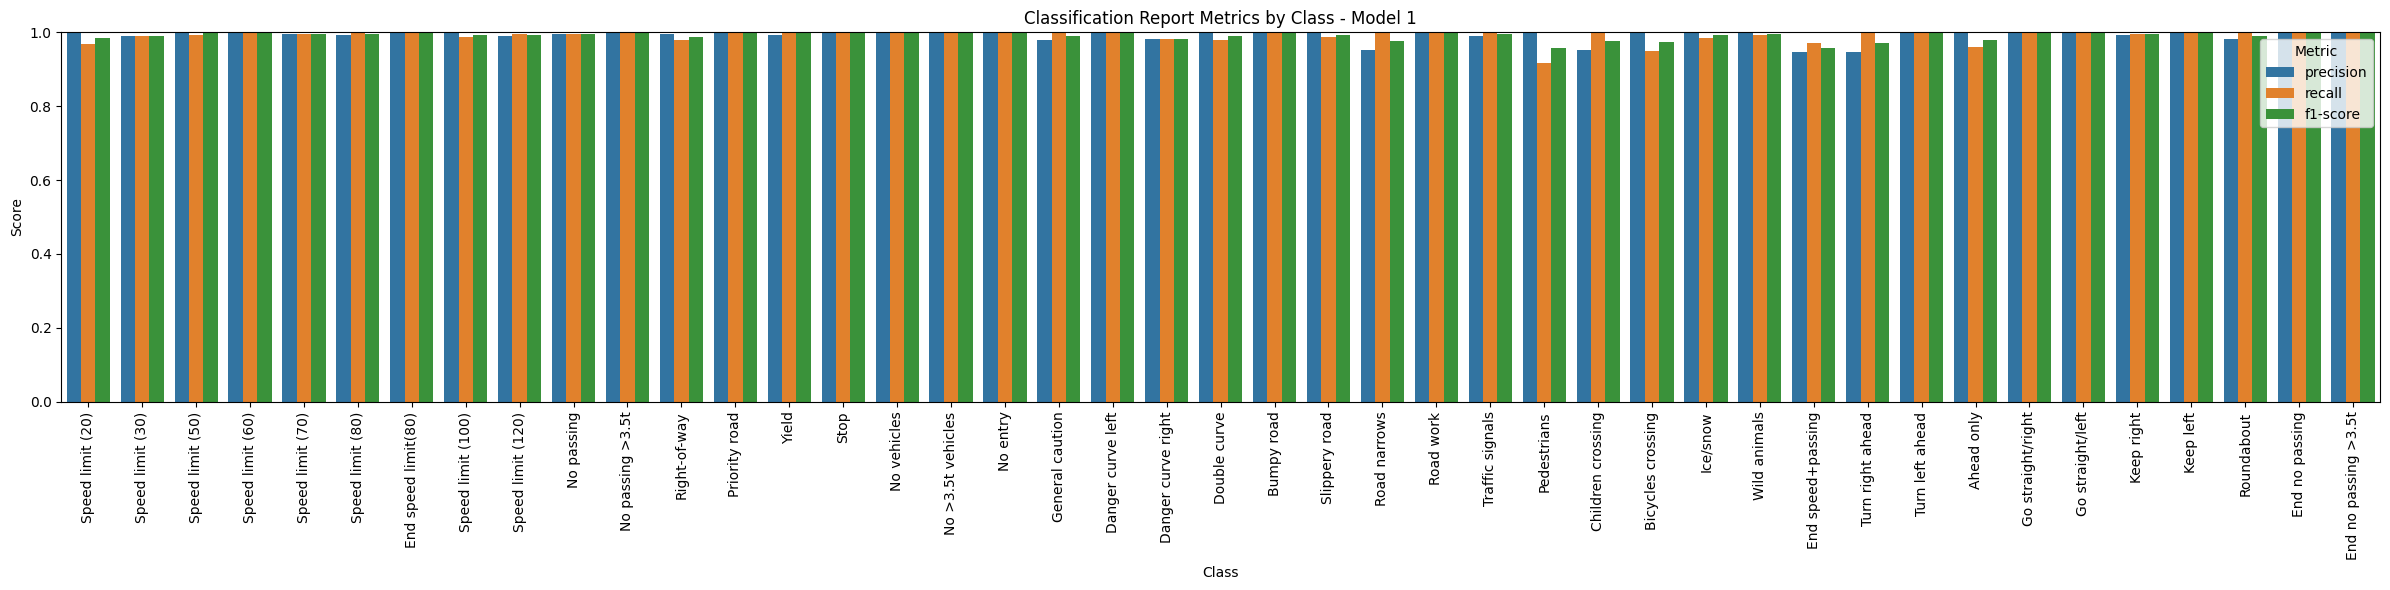

In [64]:
#the reset_index() turns the rows names into a normal column and melt make the names from teh long format into wide one.
df_melt_1 = df_report_1.reset_index().melt(
    id_vars='index',
    value_vars=['precision', 'recall', 'f1-score'],
    var_name='Metric',
    value_name='Score'
)
df_melt_1.rename(columns={'index': 'Class'}, inplace=True) #this only change th names for index to class only for the visual reasons

plt.figure(figsize=(29,15))
sns.barplot(data=df_melt_1, x='Class', y='Score', hue='Metric')
plt.title('Classification report per class - Model 1')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Plot the classification report heatmap

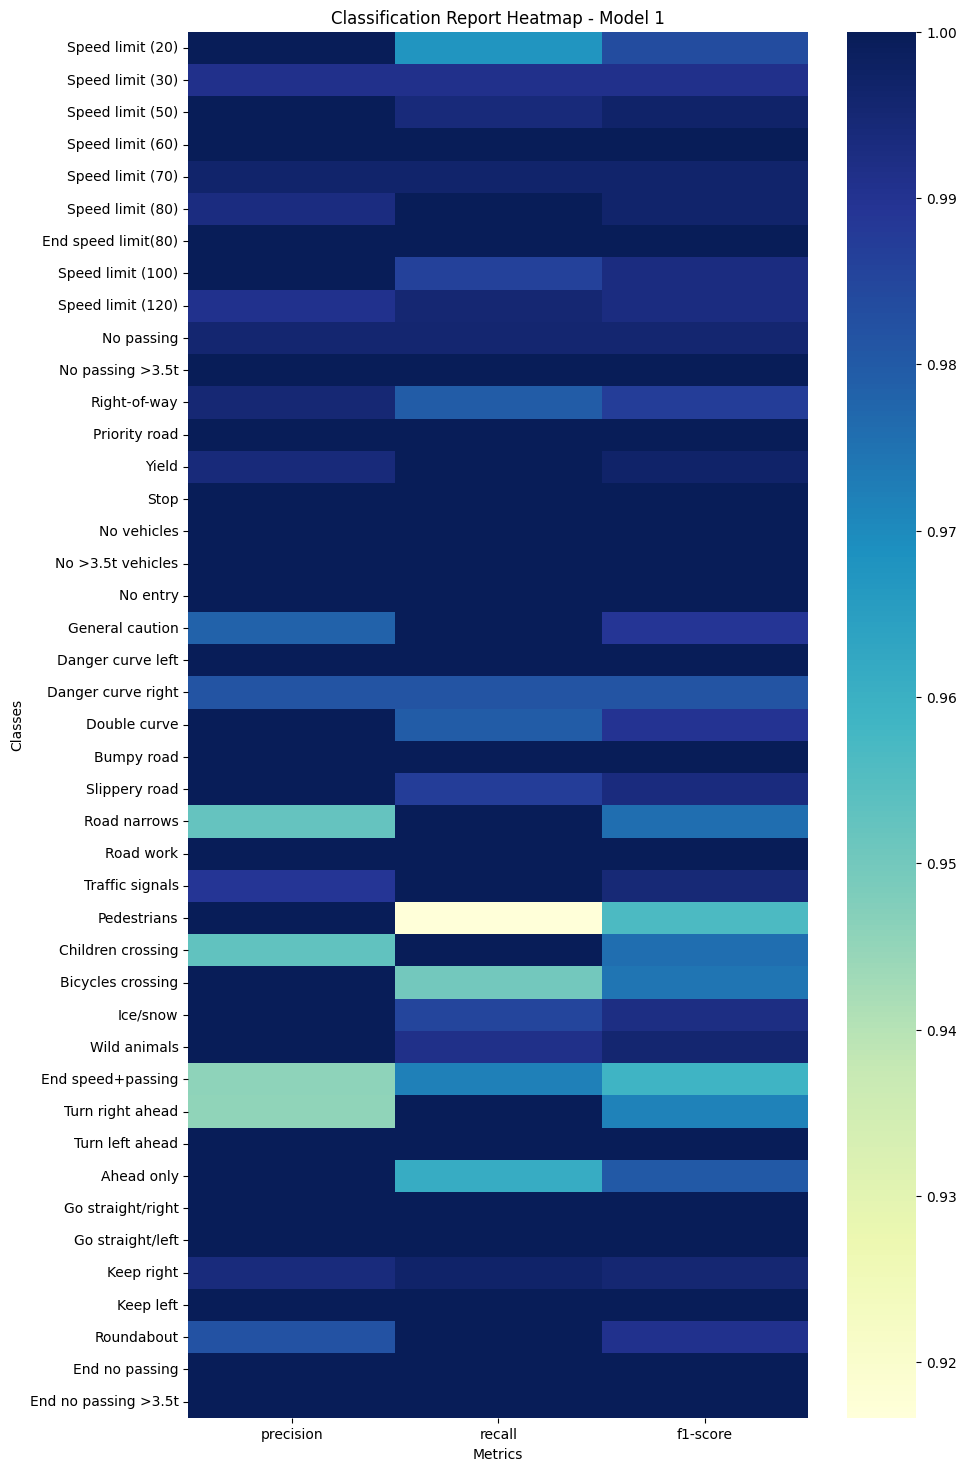

In [65]:
plt.figure(figsize=(13,18))
sns.heatmap(df_report_1[['precision', 'recall', 'f1-score']], cmap='YlGnBu', cbar=True)
plt.title('Classification report heatmap - Model 1')
plt.xlabel('Metrics')
plt.ylabel('Classes')
plt.yticks(rotation=0)
plt.show()

Sample prediction for teh first model

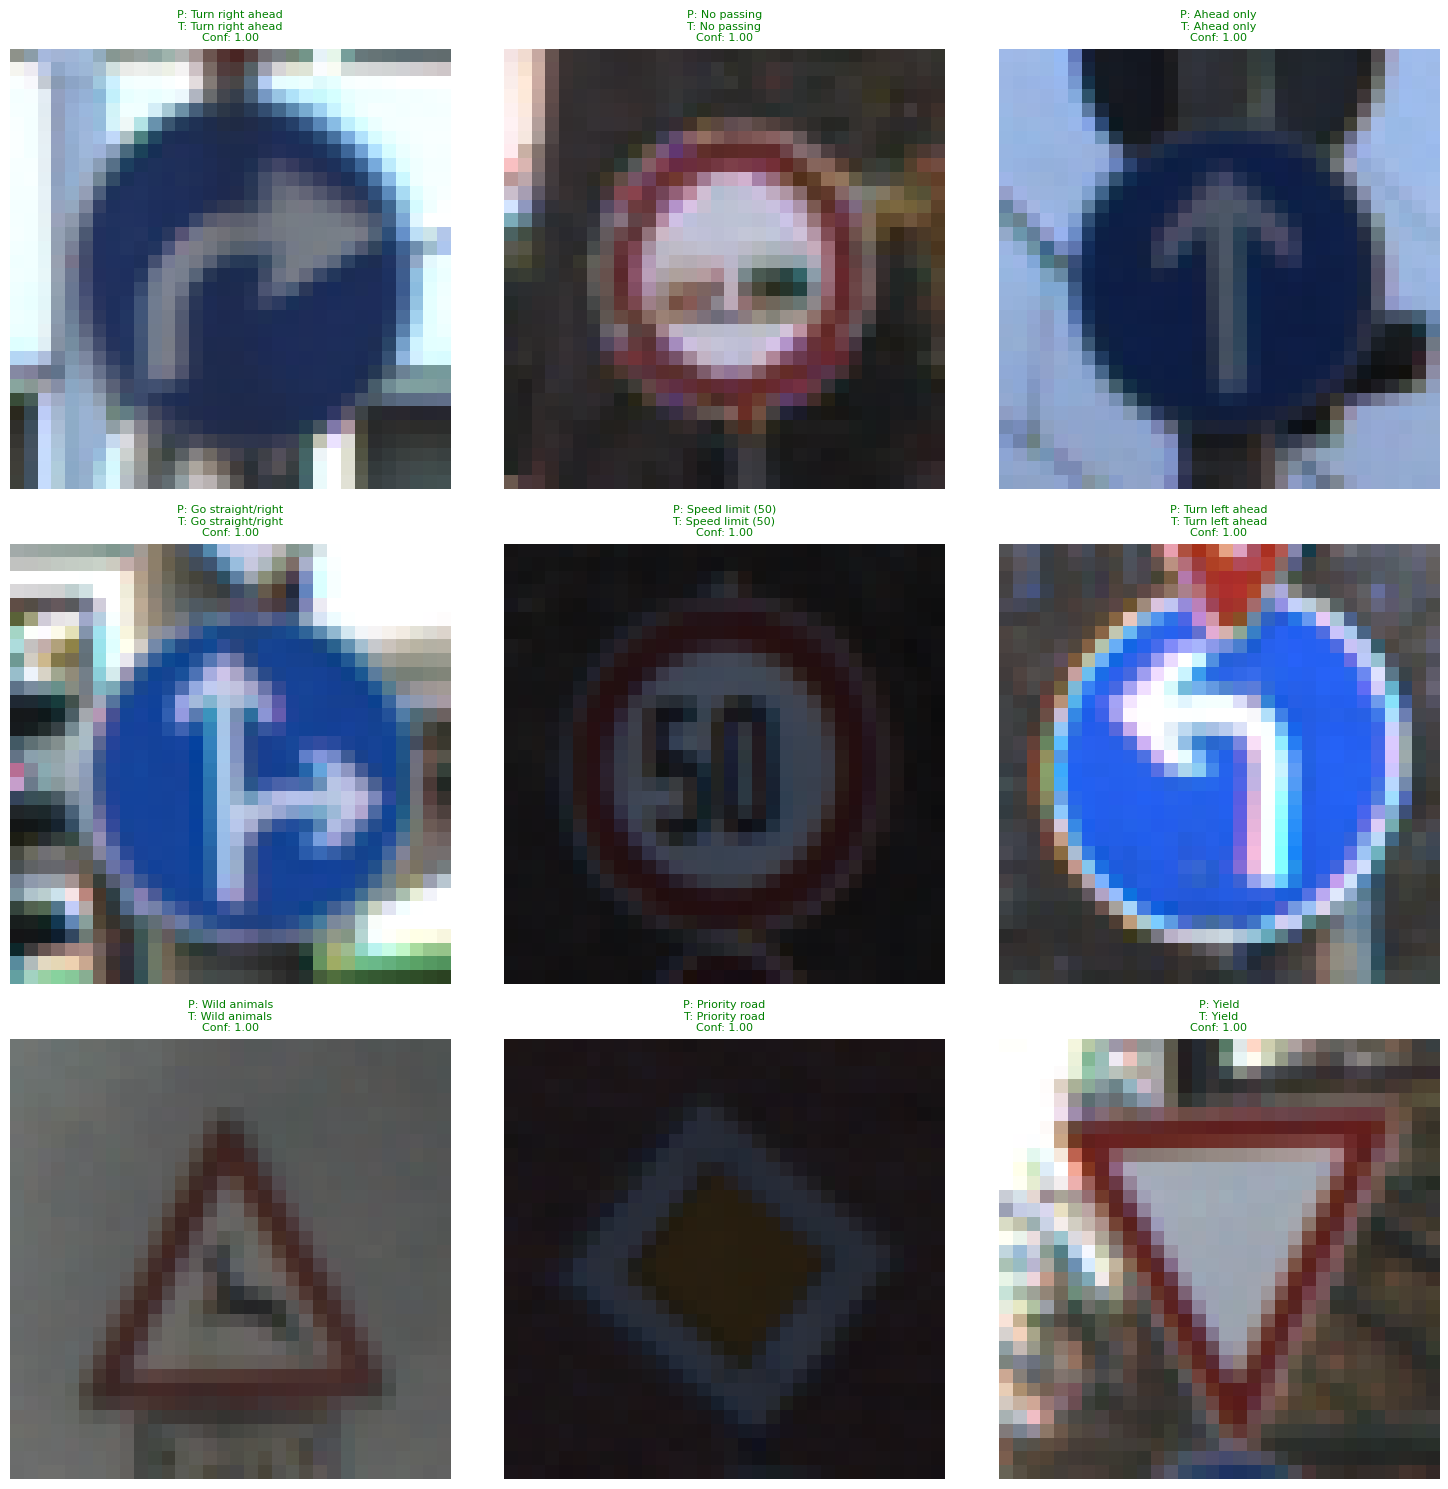

In [66]:
sample_total = min(9, len(X_test)) #this displaies 9 images or the test lenght if it is lower than 9 in our model is not the case
sample_indices = random.sample(range(len(X_test)), sample_total)# this takes the images random

fig, axes = plt.subplots(3, 3, figsize=(14,14)) #this plot them 3 in the columns and 3 in the rows and 14x14 size to see them clearly
axes = axes.flatten() #this turn the axes in 1D list

#this turn the axes off, we did this before too
for ax in axes:
    ax.axis('off')

for plot_index, sample_index in enumerate(sample_indices):
  #this two lines plot the images
    ax = axes[plot_index]
    ax.imshow(X_test[sample_index])
    true_idx = y_test_true[sample_index] #this gets the true class
    pred_idx = y_pred_1[sample_index] #this gets the predicted class
    confidence = np.max(y_pred_prob_1[sample_index]) #the highest prediction confidence
    title_color = 'green' if pred_idx == true_idx else 'red' #this makes them greenif they are correct and red if they are not
    ax.set_title(f'P: {class_names[pred_idx]}\nT: {class_names[true_idx]}\nConf: {confidence:.2f}',
                 color=title_color, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()


Preparation of true and predicted labels for first Model

In [67]:
y_test_true = np.argmax(Y_test, axis=1) if len(Y_test.shape) > 1 else Y_test

y_pred_prob_2 = model2.predict(X_test)
y_pred_2 = np.argmax(y_pred_prob_2, axis=1)

184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


Print the overall accuracy for the second model

In [68]:
print('-Test accuracy: {:.2f}%\n-Train accuracy: {:.2f}%\n-Validation accuracy: {:.2f}%'.
      format(accuracy_score(y_test_true, y_pred_2) * 100,
             history2.history['accuracy'][-1] * 100,
             history2.history['val_accuracy'][-1] * 100))

-Test accuracy: 99.78%
-Train accuracy: 99.13%
-Validation accuracy: 99.76%


Classification report for the second model

In [69]:
print('\nClassification report:\n')
print(classification_report(
    y_test_true,
    y_pred_2,
    labels=list(range(classes_list)),
    target_names=[class_names[i] for i in range(classes_list)],
    zero_division=0
))


Classification report:

                      precision    recall  f1-score   support

    Speed limit (20)       1.00      1.00      1.00        31
    Speed limit (30)       1.00      0.99      1.00       333
    Speed limit (50)       0.99      1.00      1.00       338
    Speed limit (60)       1.00      1.00      1.00       212
    Speed limit (70)       1.00      1.00      1.00       297
    Speed limit (80)       0.99      1.00      0.99       279
 End speed limit(80)       1.00      1.00      1.00        63
   Speed limit (100)       1.00      1.00      1.00       216
   Speed limit (120)       1.00      1.00      1.00       212
          No passing       1.00      1.00      1.00       221
    No passing >3.5t       1.00      1.00      1.00       302
        Right-of-way       1.00      1.00      1.00       198
       Priority road       1.00      1.00      1.00       315
               Yield       1.00      1.00      1.00       324
                Stop       1.00      1.00   

The visual graph of the confusion matrix

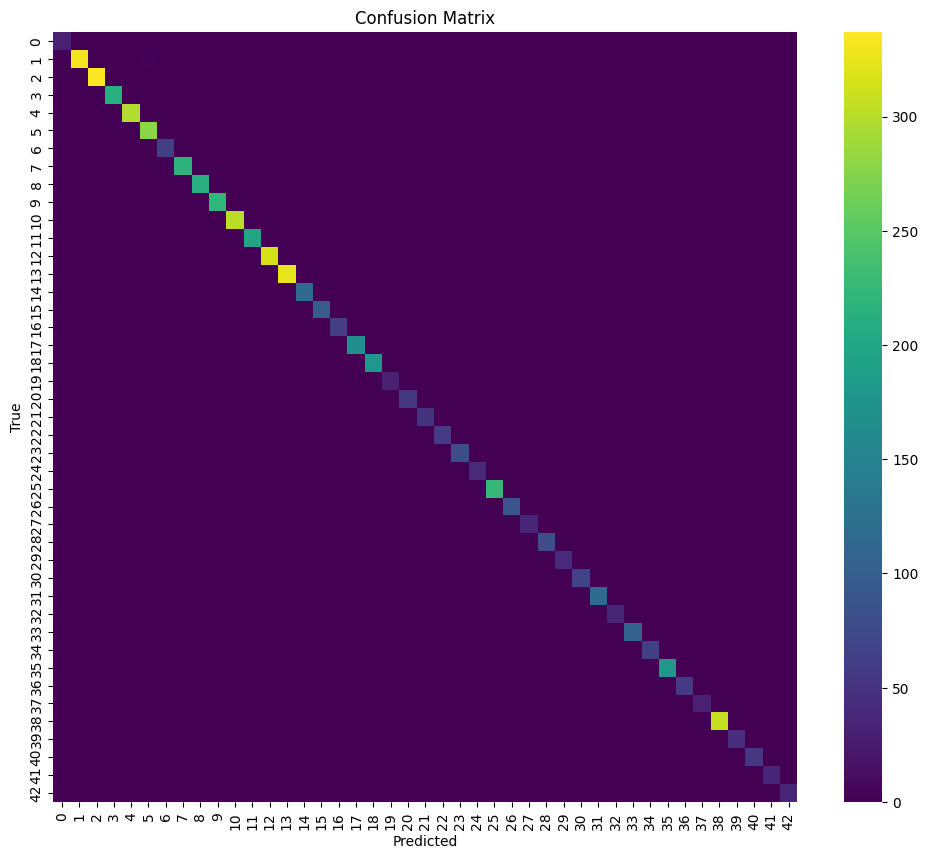

In [70]:
cm2 = confusion_matrix(y_test_true, y_pred_2, labels=list(range(classes_list))) #this calculates the confusion matrix values

plt.figure(figsize=(12,13))
sns.heatmap(cm2, cmap='magma')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


Prepare the classification report table for the second model

In [71]:
report_dict_2 = classification_report(
    y_test_true,
    y_pred_2,
    labels=list(range(classes_list)),
    target_names=[class_names[i] for i in range(classes_list)],
    output_dict=True,
    zero_division=0
)

df_report_2 = pd.DataFrame(report_dict_2).transpose().iloc[:-3, :]

Plot for the Precision, Recall, And F1-Score By Class

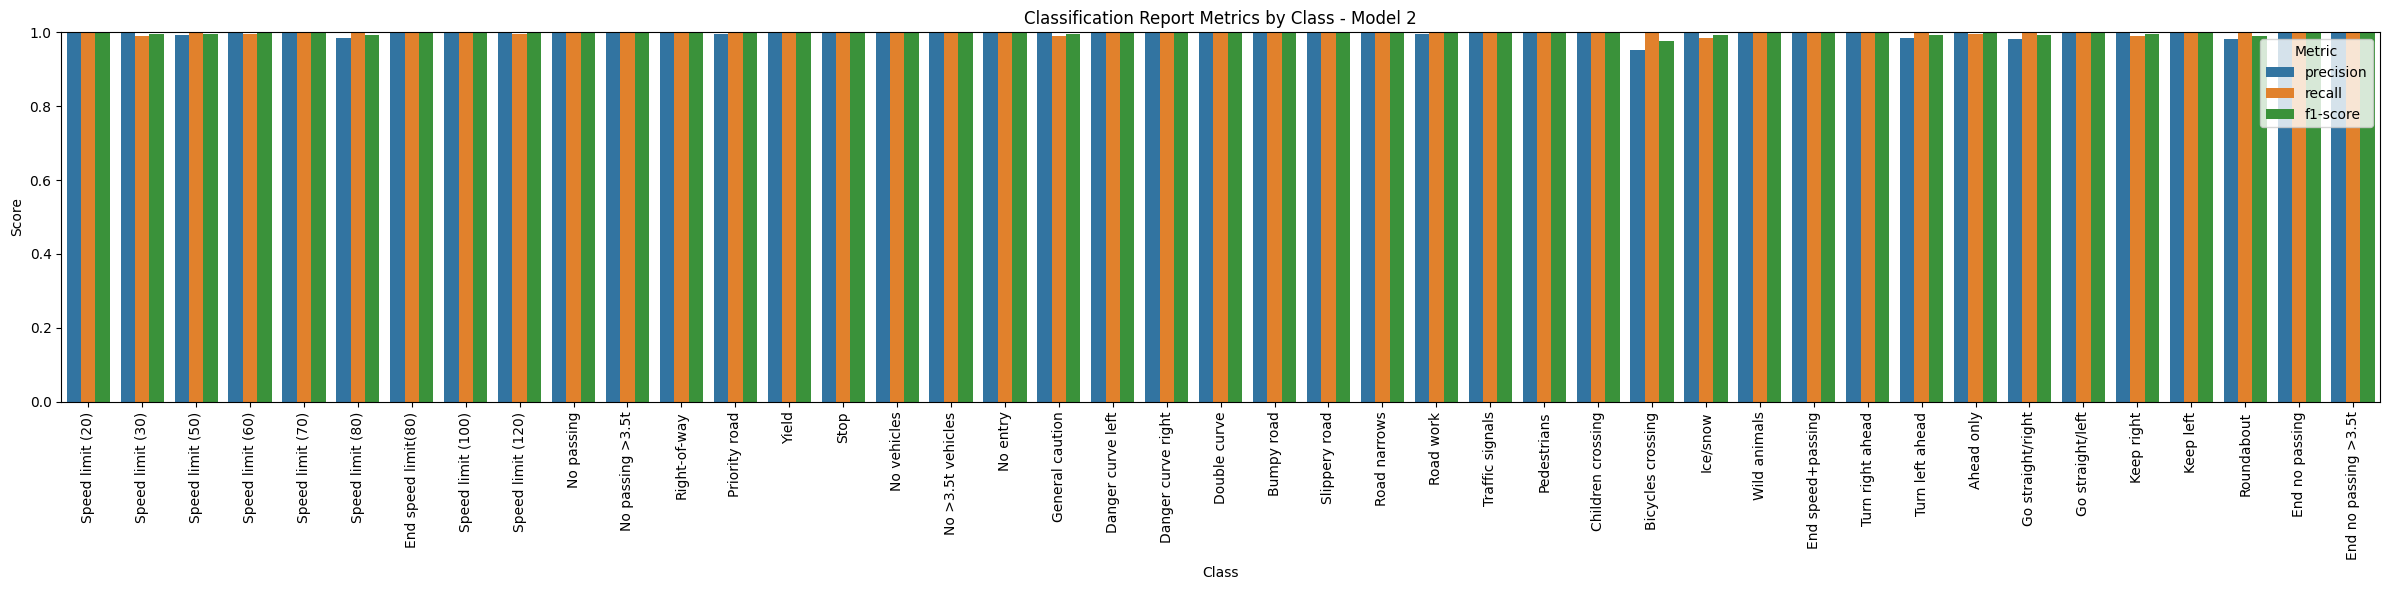

In [72]:
df_melt_2 = df_report_2.reset_index().melt(
    id_vars='index',
    value_vars=['precision', 'recall', 'f1-score'],
    var_name='Metric',
    value_name='Score'
)
df_melt_2.rename(columns={'index': 'Class'}, inplace=True)

plt.figure(figsize=(29,15))
sns.barplot(data=df_melt_2, x='Class', y='Score', hue='Metric')
plt.title('Classification report per class - Model 2')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Plot the classification report heatmap

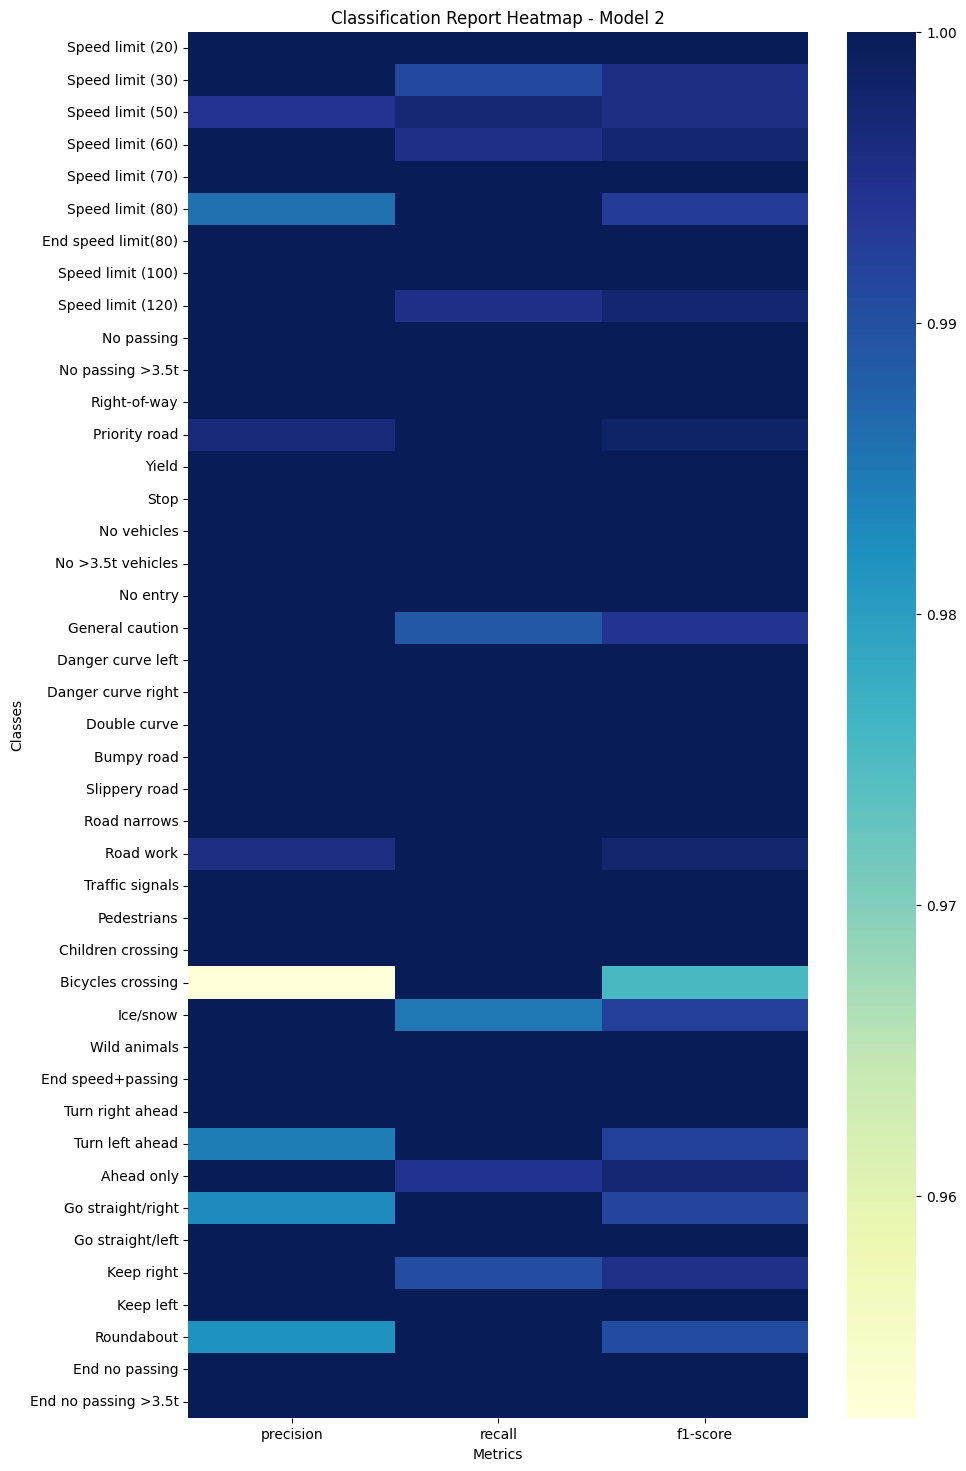

In [73]:
plt.figure(figsize=(13,18))
sns.heatmap(df_report_2[['precision', 'recall', 'f1-score']], cmap='YlGnBu', cbar=True)
plt.title('Classification report heatmap - Model 2')
plt.xlabel('Metrics')
plt.ylabel('Classes')
plt.yticks(rotation=0)
plt.show()


sample prediction for the second model

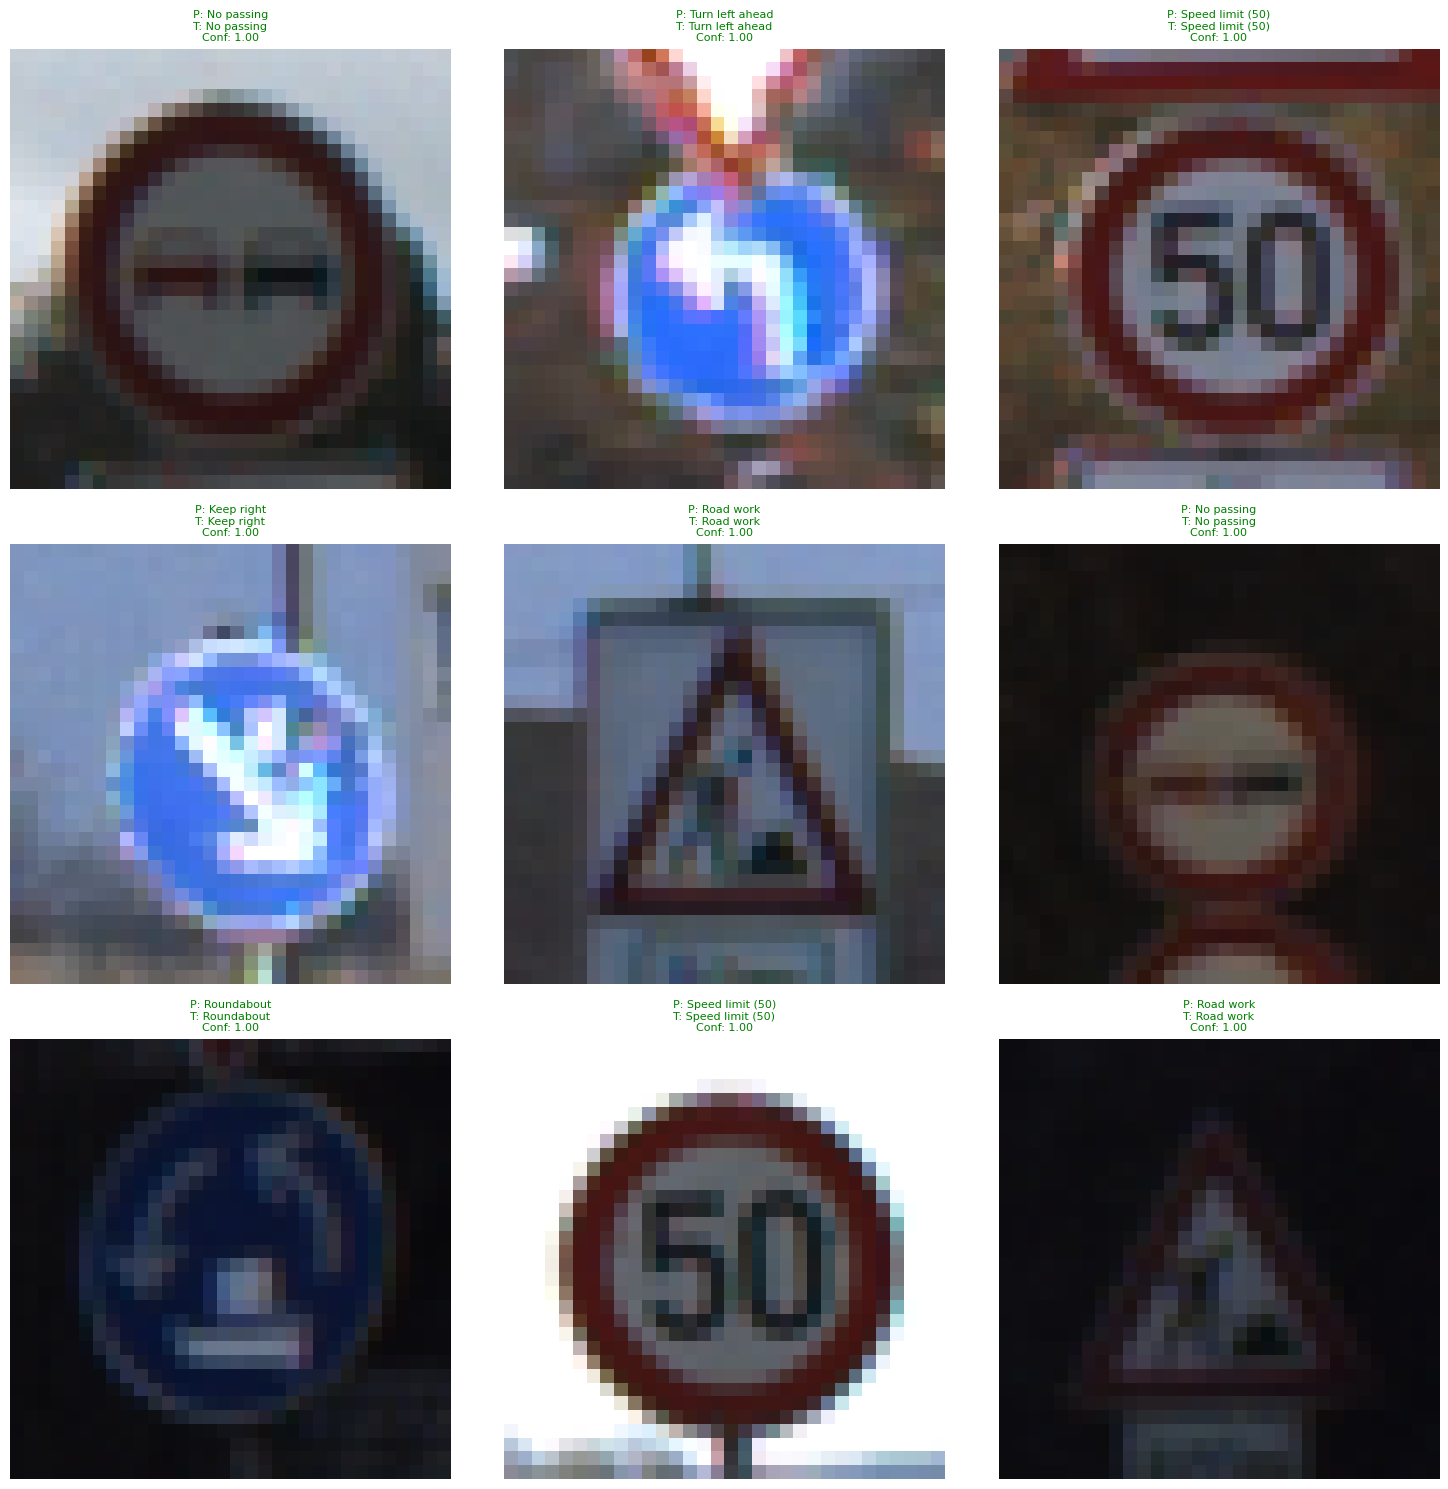

In [74]:
sample_total = min(9, len(X_test))
sample_indices = random.sample(range(len(X_test)), sample_total)

fig, axes = plt.subplots(3, 3, figsize=(15,15))
axes = axes.flatten()

for ax in axes:
    ax.axis('off')

for plot_index, sample_index in enumerate(sample_indices):
    ax = axes[plot_index]
    ax.imshow(X_test[sample_index])
    true_idx = y_test_true[sample_index]
    pred_idx = y_pred_2[sample_index]
    confidence = np.max(y_pred_prob_2[sample_index])
    title_color = 'green' if pred_idx == true_idx else 'red'
    ax.set_title(f'P: {class_names[pred_idx]}\nT: {class_names[true_idx]}\nConf: {confidence:.2f}',
                 color=title_color, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()


# Thank You